### MAIN RESULTS

pCO₂ uncertainty matched for 49,528 / 49,528 rows
Created floats_df_low and floats_df_high with adjusted pCO₂ values.
Filled SOCAT uncertainty where missing. Remaining NaNs: 0
Created combined_df_low/high with uncertainty-adjusted pCO₂.
Processed: socat_df — 5,888,602 rows
Processed: socat_df_low — 5,888,602 rows
Processed: socat_df_high — 5,888,602 rows
Processed: floats_df — 49,528 rows
Processed: floats_df_low — 49,528 rows
Processed: floats_df_high — 49,528 rows
Processed: combined_df — 5,938,130 rows
Processed: combined_df_low — 5,938,130 rows
Processed: combined_df_high — 5,938,130 rows


/tmp/ipykernel_1013634/2054804441.py:296: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.04, 1, 1])


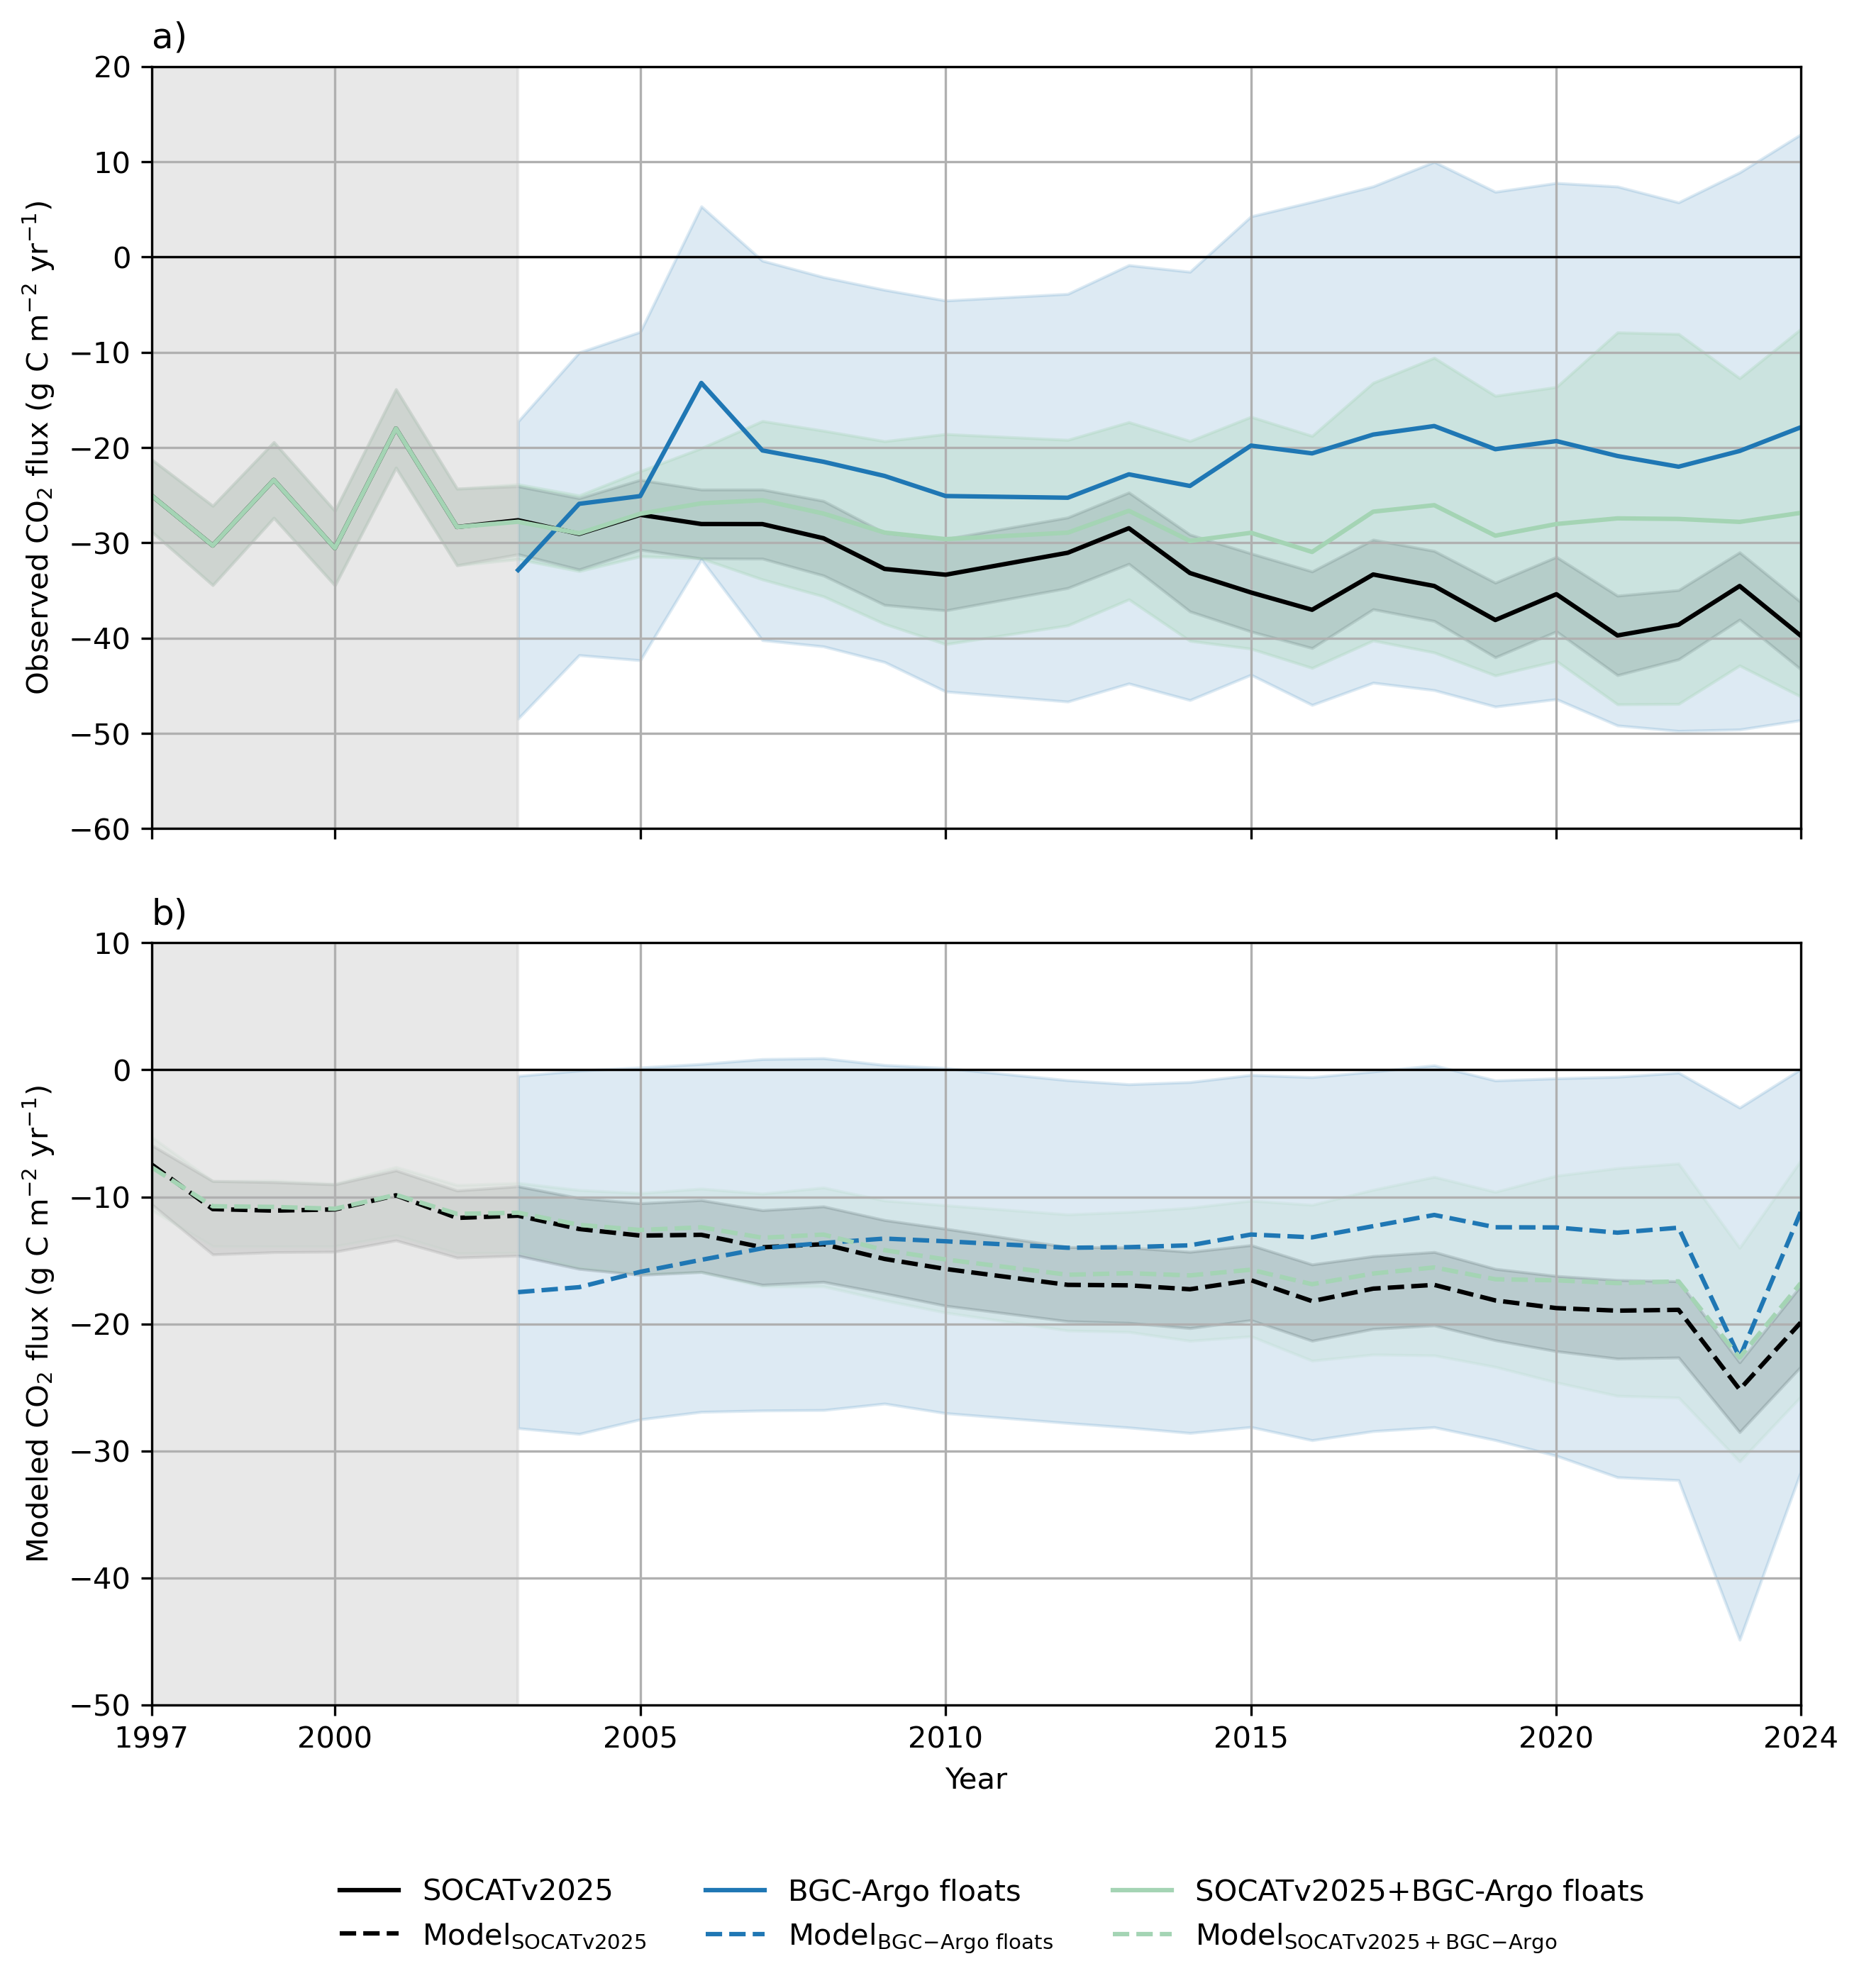

Mean Southern Ocean CO₂ uptake (Pg C/yr), naive full-area scaling (2003–2024):
FLOATS_predictions_PgC_yr_fullarea: -0.98
FLOATS_predictions_high_PgC_yr_fullarea: -0.02
FLOATS_predictions_low_PgC_yr_fullarea: -2.06
Floats_PgC_yr_fullarea: -1.52
Floats_high_PgC_yr_fullarea: 0.10
Floats_low_PgC_yr_fullarea: -3.14
SOCAT+Floats_PgC_yr_fullarea: -1.95
SOCAT+Floats_high_PgC_yr_fullarea: -1.15
SOCAT+Floats_low_PgC_yr_fullarea: -2.76
SOCAT_AND_FLOATS_predictions_PgC_yr_fullarea: -1.07
SOCAT_AND_FLOATS_predictions_high_PgC_yr_fullarea: -0.68
SOCAT_AND_FLOATS_predictions_low_PgC_yr_fullarea: -1.47
SOCAT_PgC_yr_fullarea: -2.31
SOCAT_high_PgC_yr_fullarea: -2.05
SOCAT_low_PgC_yr_fullarea: -2.58
SOCAT_predictions_PgC_yr_fullarea: -1.16
SOCAT_predictions_high_PgC_yr_fullarea: -0.97
SOCAT_predictions_low_PgC_yr_fullarea: -1.38


,year,SOCAT_PgCyr_cov,Floats_PgCyr_cov,SOCAT+Floats_PgCyr_cov
0,1997,-0.029239,NaN,-0.029239
1,1998,-0.089966,NaN,-0.089966
2,1999,-0.037850,NaN,-0.037850
3,2000,-0.096164,NaN,-0.096164
4,2001,-0.077429,NaN,-0.077429


In [2]:
# --- imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyseaflux

# =========================
# 1) LOAD DATA (your paths)
# =========================
predictions_socat = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_only_models.csv")
predictions_socat_low = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_only_models_minus_unc_models.csv")
predictions_socat_high = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_only_models_plus_unc_models.csv")
predictions_floats = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_FLOATS_only_models.csv")
predictions_floats_low = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_FLOATS_only_minus_unc_models.csv")
predictions_floats_high = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_FLOATS_only_plus_unc_models.csv")
predictions_socat_and_floats = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_AND_FLOATS_models.csv")
predictions_socat_and_floats_low = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_AND_FLOATS_MINUS_UNC_models.csv")
predictions_socat_and_floats_high = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/matrix_predictions/pco2_prediction_matrix_SOCAT_AND_FLOATS_PLUS_UNC_models.csv")

socat_df = pd.read_csv('/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/MODEL_SOCAT_ONLY_OBS/processing_steps/SOCATv2025_SO_clean_SLA_RRS_CHL_WIND_PAR_CO2ATM_MLD_COORDS_PCO2.csv', low_memory=False)

# Uncertainty variants for SOCAT (±4 µatm)
socat_df_low = socat_df.copy()
socat_df_low['pco2'] = socat_df_low['pco2'] - 4
socat_df_high = socat_df.copy()
socat_df_high['pco2'] = socat_df_high['pco2'] + 4

# Column rename for flux calc
socat_df.rename(columns={'sst_degC': 'temperature'}, inplace=True)
socat_df_low.rename(columns={'sst_degC': 'temperature'}, inplace=True)
socat_df_high.rename(columns={'sst_degC': 'temperature'}, inplace=True)

# Floats + per-profile pCO2 uncertainty
uncer = pd.read_csv("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/data/BGC-ARGO/BGC-ARGO_mean_0-10m_surface_pco2_all_profiles_with_uncertainty.csv")
floats_df = pd.read_csv('/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/MODEL_FLOATS/processing_steps/BGC-ARGO_mean_0-10m_surface_pco2_all_profiles_US_pco2_SLA_RRS_CHL_PAR_WIND_CO2ATM_MLD_COORDS.csv', low_memory=False)

# Merge uncertainty onto floats
uncer['datetime'] = pd.to_datetime(uncer['datetime']).dt.round('1s')
floats_df['datetime'] = pd.to_datetime(floats_df['datetime']).dt.round('1s')
uncer['latitude'] = uncer['latitude'].round(4)
uncer['longitude'] = uncer['longitude'].round(4)
floats_df['latitude'] = floats_df['latitude'].round(4)
floats_df['longitude'] = floats_df['longitude'].round(4)
merge_keys = ['platform_number', 'cycle_number']
floats_df = floats_df.merge(uncer[merge_keys + ['pco2_uncertainty']], on=merge_keys, how='left')

print(f"pCO₂ uncertainty matched for {floats_df['pco2_uncertainty'].notna().sum():,} / {len(floats_df):,} rows")

# Build ±unc variants for floats
floats_df_low = floats_df.copy()
floats_df_high = floats_df.copy()
floats_df_low['pco2']  = floats_df_low['pco2']  - floats_df_low['pco2_uncertainty']
floats_df_high['pco2'] = floats_df_high['pco2'] + floats_df_high['pco2_uncertainty']
print("Created floats_df_low and floats_df_high with adjusted pCO₂ values.")

# Combined obs + fill SOCAT uncertainty with 4 µatm
combined_df = pd.concat([socat_df, floats_df], ignore_index=True)
combined_df['pco2_uncertainty'] = combined_df.apply(
    lambda r: 4.0 if pd.isna(r.get('pco2_uncertainty')) and pd.notna(r.get('expocode')) else r.get('pco2_uncertainty'),
    axis=1
)
print(f"Filled SOCAT uncertainty where missing. Remaining NaNs: {combined_df['pco2_uncertainty'].isna().sum()}")

combined_df_low = combined_df.copy()
combined_df_high = combined_df.copy()
combined_df_low['pco2']  = combined_df_low['pco2']  - combined_df_low['pco2_uncertainty']
combined_df_high['pco2'] = combined_df_high['pco2'] + combined_df_high['pco2_uncertainty']
print("Created combined_df_low/high with uncertainty-adjusted pCO₂.")

# =====================================
# 2) FLUX FUNCTIONS (obs & predictions)
# =====================================
def compute_co2_flux_from_predictions(df):
    wind_speed = df["wind_speed"].values
    temp_C     = df["temperature"].values
    salinity   = df["salinity"].values
    pCO2_sw    = df["ensemble_pco2_pred"].values
    pCO2_air   = df["atm_co2"].values
    pres_hPa   = df["air_pressure_hpa"].values if "air_pressure_hpa" in df else 1013.25
    k_w_cmhr   = pyseaflux.gas_transfer_velocity.k_Ho06(wind_speed, temp_C)
    flux_mol_m2_day = pyseaflux.flux_calculations.flux_bulk(temp_C, salinity, pCO2_sw, pCO2_air, pres_hPa, k_w_cmhr)
    return flux_mol_m2_day * 12.01  # g C m^-2 day^-1

def compute_co2_flux_from_obs(df):
    wind_speed = df["wind_speed"].values
    temp_C     = df["temperature"].values
    salinity   = df["salinity"].values
    pCO2_sw    = df["pco2"].values
    pCO2_air   = df["atm_co2"].values
    pres_hPa   = df["air_pressure_hpa"].values if "air_pressure_hpa" in df else 1013.25
    k_w_cmhr   = pyseaflux.gas_transfer_velocity.k_Ho06(wind_speed, temp_C)
    flux_mol_m2_day = pyseaflux.flux_calculations.flux_bulk(temp_C, salinity, pCO2_sw, pCO2_air, pres_hPa, k_w_cmhr)
    return flux_mol_m2_day * 12.01  # g C m^-2 day^-1

# ============================================
# 3) BIN TO 1° GRID (kept as in your pipeline)
# ============================================
def bin_flux_to_grid(df, lat_col='latitude', lon_col='longitude', year_col='year', flux_col='flux_gC_m2_month'):
    df = df.copy()
    df['lat_bin'] = df[lat_col].astype(int)
    df['lon_bin'] = df[lon_col].astype(int)
    binned = df.groupby(['lat_bin', 'lon_bin', df[year_col]])[flux_col].mean().reset_index()
    binned.rename(columns={flux_col: 'mean_flux'}, inplace=True)
    return binned

# ======================================================
# 4) COMPUTE MONTHLY FLUX, THEN BIN (OBS incl. variants)
# ======================================================
for df_name, df in {
    "socat_df": socat_df,
    "socat_df_low": socat_df_low,
    "socat_df_high": socat_df_high,
    "floats_df": floats_df,
    "floats_df_low": floats_df_low,
    "floats_df_high": floats_df_high,
    "combined_df": combined_df,
    "combined_df_low": combined_df_low,
    "combined_df_high": combined_df_high,
}.items():
    # datetime column differs by dataset
    df['datetime'] = pd.to_datetime(df['date']) if 'date' in df.columns else pd.to_datetime(df['datetime'])
    df['flux_gC_m2_day']   = compute_co2_flux_from_obs(df)
    df['flux_gC_m2_month'] = df['flux_gC_m2_day'] * df['datetime'].dt.days_in_month
    df['year'] = df['datetime'].dt.year
    print(f"Processed: {df_name} — {len(df):,} rows")

# Bin all obs variants
socat_binned_flux         = bin_flux_to_grid(socat_df,         flux_col='flux_gC_m2_month')
floats_binned_flux        = bin_flux_to_grid(floats_df,        flux_col='flux_gC_m2_month')
combined_binned_flux      = bin_flux_to_grid(combined_df,      flux_col='flux_gC_m2_month')
socat_binned_flux_low     = bin_flux_to_grid(socat_df_low,     flux_col='flux_gC_m2_month')
socat_binned_flux_high    = bin_flux_to_grid(socat_df_high,    flux_col='flux_gC_m2_month')
floats_binned_flux_low    = bin_flux_to_grid(floats_df_low,    flux_col='flux_gC_m2_month')
floats_binned_flux_high   = bin_flux_to_grid(floats_df_high,   flux_col='flux_gC_m2_month')
combined_binned_flux_low  = bin_flux_to_grid(combined_df_low,  flux_col='flux_gC_m2_month')
combined_binned_flux_high = bin_flux_to_grid(combined_df_high, flux_col='flux_gC_m2_month')

# ======================================
# 5) AREA WEIGHTS + AREA-WEIGHTED MEANS
# ======================================
R = 6371000.0
deg2rad = np.pi / 180.0
# lat_bin is floor(lat) → integers …,-89,…,+89
lat_centers = np.arange(-89.5, 90.5, 1.0)[:-1]
band_areas = (2*np.pi*R**2) * (np.sin((lat_centers+0.5)*deg2rad) - np.sin((lat_centers-0.5)*deg2rad))
cell_area_by_lat = pd.Series(band_areas/360.0, index=np.arange(-89, 90, 1))  # m^2 per 1°x1° cell

def add_area_weights(df, lat_col='lat_bin'):
    return df.merge(cell_area_by_lat.rename('cell_area_m2'),
                    left_on=lat_col, right_index=True, how='left')

def area_weighted_year_mean(binned_df, value_col='mean_flux'):
    # returns area-weighted mean flux (g C m^-2 month-equivalent); multiply by 12 later for g C m^-2 yr^-1
    df = add_area_weights(binned_df)
    out = (
        df.groupby('year')
          .apply(lambda d: (d[value_col]*d['cell_area_m2']).sum() / d['cell_area_m2'].sum())
          .reset_index(name='aw_mean_flux')
    )
    return out

def area_integrated_year_total(binned_df, value_col='mean_flux'):
    # returns integrated total over *covered* area (Pg C yr^-1) after month→year scaling
    df = add_area_weights(binned_df)
    out = (
        df.groupby('year')
          .apply(lambda d: (d[value_col]*12.0 * d['cell_area_m2']).sum() / 1e15)
          .reset_index(name='PgCyr_over_covered')
    )
    return out

# Area-weighted yearly means (OBS)
summary_socat         = area_weighted_year_mean(socat_binned_flux      ).rename(columns={'aw_mean_flux':'SOCAT'})
summary_floats        = area_weighted_year_mean(floats_binned_flux     ).rename(columns={'aw_mean_flux':'Floats'})
summary_combined      = area_weighted_year_mean(combined_binned_flux   ).rename(columns={'aw_mean_flux':'SOCAT+Floats'})

summary_socat_low     = area_weighted_year_mean(socat_binned_flux_low  ).rename(columns={'aw_mean_flux':'SOCAT_low'})
summary_socat_high    = area_weighted_year_mean(socat_binned_flux_high ).rename(columns={'aw_mean_flux':'SOCAT_high'})
summary_floats_low    = area_weighted_year_mean(floats_binned_flux_low ).rename(columns={'aw_mean_flux':'Floats_low'})
summary_floats_high   = area_weighted_year_mean(floats_binned_flux_high).rename(columns={'aw_mean_flux':'Floats_high'})
summary_combined_low  = area_weighted_year_mean(combined_binned_flux_low ).rename(columns={'aw_mean_flux':'SOCAT+Floats_low'})
summary_combined_high = area_weighted_year_mean(combined_binned_flux_high).rename(columns={'aw_mean_flux':'SOCAT+Floats_high'})

# (Optional) integrated totals over covered area (Pg C/yr) — handy for tables
socat_tot_covered    = area_integrated_year_total(socat_binned_flux     ).rename(columns={'PgCyr_over_covered':'SOCAT_PgCyr_cov'})
floats_tot_covered   = area_integrated_year_total(floats_binned_flux    ).rename(columns={'PgCyr_over_covered':'Floats_PgCyr_cov'})
combined_tot_covered = area_integrated_year_total(combined_binned_flux  ).rename(columns={'PgCyr_over_covered':'SOCAT+Floats_PgCyr_cov'})

# ======================================================
# 6) PREDICTIONS → BIN → AREA-WEIGHTED YEARLY MEAN
# ======================================================
def process_prediction_flux(df, label):
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df['flux_gC_m2_day']   = compute_co2_flux_from_predictions(df)
    df['flux_gC_m2_month'] = df['flux_gC_m2_day'] * df['time'].dt.days_in_month
    df['year'] = df['time'].dt.year
    df['lat_bin'] = df['latitude'].astype(int)
    df['lon_bin'] = df['longitude'].astype(int)
    binned = (df.groupby(['lat_bin','lon_bin','year'])['flux_gC_m2_month']
                .mean().reset_index()
                .rename(columns={'flux_gC_m2_month':'mean_flux'}))
    aw = area_weighted_year_mean(binned, value_col='mean_flux')
    aw.rename(columns={'aw_mean_flux': label}, inplace=True)
    return aw

summary_preds_socat             = process_prediction_flux(predictions_socat,            'SOCAT_predictions')
summary_preds_socat_low             = process_prediction_flux(predictions_socat_low,            'SOCAT_predictions_low')
summary_preds_socat_high             = process_prediction_flux(predictions_socat_high,            'SOCAT_predictions_high')
summary_preds_floats            = process_prediction_flux(predictions_floats,           'FLOATS_predictions')
summary_preds_floats_low        = process_prediction_flux(predictions_floats_low,       'FLOATS_predictions_low')
summary_preds_floats_high       = process_prediction_flux(predictions_floats_high,      'FLOATS_predictions_high')
summary_preds_socat_and_floats  = process_prediction_flux(predictions_socat_and_floats, 'SOCAT_AND_FLOATS_predictions')
summary_preds_socat_and_floats_low  = process_prediction_flux(predictions_socat_and_floats_low, 'SOCAT_AND_FLOATS_predictions_low')
summary_preds_socat_and_floats_high  = process_prediction_flux(predictions_socat_and_floats_high, 'SOCAT_AND_FLOATS_predictions_high')

# ==========================
# 7) MERGE + FINAL CLEANUPS
# ==========================
yearly_flux_summary = (
    summary_preds_socat
      .merge(summary_socat, on='year', how='outer')            
      .merge(summary_preds_socat_low, on='year', how='outer')
      .merge(summary_preds_socat_high, on='year', how='outer')
      .merge(summary_preds_floats, on='year', how='outer')
      .merge(summary_preds_floats_low, on='year', how='outer')
      .merge(summary_preds_floats_high, on='year', how='outer')
      .merge(summary_preds_socat_and_floats, on='year', how='outer')
      .merge(summary_preds_socat_and_floats_low, on='year', how='outer')
      .merge(summary_preds_socat_and_floats_high, on='year', how='outer')
      .merge(summary_floats, on='year', how='outer')
      .merge(summary_combined, on='year', how='outer')
      .merge(summary_socat_low, on='year', how='outer')
      .merge(summary_socat_high, on='year', how='outer')
      .merge(summary_floats_low, on='year', how='outer')
      .merge(summary_floats_high, on='year', how='outer')
      .merge(summary_combined_low, on='year', how='outer')
      .merge(summary_combined_high, on='year', how='outer')
      .sort_values('year')
)


# No floats predictions pre-2003
yearly_flux_summary.loc[yearly_flux_summary['year'] < 2003, 'FLOATS_predictions'] = np.nan
yearly_flux_summary.loc[yearly_flux_summary['year'] < 2003, 'FLOATS_predictions_low'] = np.nan

# Convert monthly-equivalent g C m^-2 to annual g C m^-2 yr^-1
for col in yearly_flux_summary.columns:
    if col != 'year':
        yearly_flux_summary[col] = yearly_flux_summary[col] * 12.0

# =================
# 8) PLOTTING (Fig)
# =================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), dpi=300, sharex=True, gridspec_kw={'hspace': 0.15})

# Observations
line1, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT'],           label='SOCATv2025',                    c='k', zorder=2)
line3, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['Floats'],          label='BGC-Argo floats',               c='tab:blue', zorder=2)
line5, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT+Floats'],    label='SOCATv2025+BGC-Argo floats',    c='#A4D4B4', zorder=2)

ax1.fill_between(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_low'],         yearly_flux_summary['SOCAT_high'],         color='k', alpha=0.15, zorder=1)
ax1.fill_between(yearly_flux_summary['year'], yearly_flux_summary['Floats_low'],        yearly_flux_summary['Floats_high'],        color='tab:blue', alpha=0.15, zorder=1)
ax1.fill_between(yearly_flux_summary['year'], yearly_flux_summary['SOCAT+Floats_low'],  yearly_flux_summary['SOCAT+Floats_high'],  color='#A4D4B4', alpha=0.30, zorder=1)

ax1.set_ylabel(r'Observed CO$_2$ flux (g C m$^{-2}$ yr$^{-1}$)')
ax1.set_xlim(1997, 2024)
ax1.set_ylim(-60, 20)
ax1.axhline(0, c='k', lw=0.8)
ax1.grid(True)
ax1.axvspan(1997, 2003, color='lightgray', alpha=0.5, zorder=1)

# Predictions
line2, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_predictions'],            label=r'Model$_{\mathrm{SOCATv2025}}$',                 linestyle='--', c='k', zorder=2)
ax2.fill_between(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_predictions_low'], yearly_flux_summary['SOCAT_predictions_high'], color='k', alpha=0.15, zorder=1, label='_nolegend_')
line4, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['FLOATS_predictions'],           label=r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',       linestyle='--', c='tab:blue', zorder=2)
ax2.fill_between(yearly_flux_summary['year'], yearly_flux_summary['FLOATS_predictions_low'], yearly_flux_summary['FLOATS_predictions_high'], color='tab:blue', alpha=0.15, zorder=1, label='_nolegend_')
line6, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_AND_FLOATS_predictions'], label=r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',   linestyle='--', c='#A4D4B4', zorder=2)
ax2.fill_between(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_AND_FLOATS_predictions_low'], yearly_flux_summary['SOCAT_AND_FLOATS_predictions_high'], color='#A4D4B4', alpha=0.15, zorder=1, label='_nolegend_')

ax2.set_xlabel('Year')
ax2.set_ylabel(r'Modeled CO$_2$ flux (g C m$^{-2}$ yr$^{-1}$)')
ax2.set_xlim(1997, 2024)
ax2.set_xticks([1997, 2000, 2005, 2010, 2015, 2020, 2024])
ax2.set_ylim(-50, 10)
ax2.axhline(0, c='k', lw=0.8)
ax2.grid(True)
ax2.axvspan(1997, 2003, color='lightgray', alpha=0.5, zorder=1)

# Labels + legend
ax1.text(0, 1.06, 'a)', transform=ax1.transAxes, fontsize=12, va='top', ha='left')
ax2.text(0, 1.06, 'b)', transform=ax2.transAxes, fontsize=12, va='top', ha='left')
handles = [line1, line2, line3, line4, line5, line6]
labels  = ['SOCATv2025', r'Model$_{\mathrm{SOCATv2025}}$', 'BGC-Argo floats', r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$', 'SOCATv2025+BGC-Argo floats', r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$']
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.52, -0.02))
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/figs/main_result_obs_vs_models.png", dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 9) Naive full-basin scaling (for Table X flow)
# ============================================================
OCEAN_AREA_M2 = 7e13  # whole Southern Ocean area you use

for col in yearly_flux_summary.columns:
    if col != 'year':
        yearly_flux_summary[col + '_PgC_yr_fullarea'] = yearly_flux_summary[col] * OCEAN_AREA_M2 / 1e15

pgc_cols = [c for c in yearly_flux_summary.columns if c.endswith('_PgC_yr_fullarea')]
filtered = yearly_flux_summary[(yearly_flux_summary['year'] >= 2003) & (yearly_flux_summary['year'] <= 2024)]
mean_uptake = filtered[pgc_cols].mean().sort_index()

print("Mean Southern Ocean CO₂ uptake (Pg C/yr), naive full-area scaling (2003–2024):")
for label, value in mean_uptake.items():
    print(f"{label}: {value:.2f}")

# ============================================================
# 10) OPTIONAL: Covered-area totals (Pg C/yr) for obs (sanity)
# ============================================================
covered_totals = (
    socat_tot_covered
      .merge(floats_tot_covered, on='year', how='outer')
      .merge(combined_tot_covered, on='year', how='outer')
      .sort_values('year')
)
covered_totals.head()


In [3]:
yearly_flux_summary

,year,SOCAT_predictions,SOCAT,SOCAT_predictions_low,SOCAT_predictions_high,FLOATS_predictions,FLOATS_predictions_low,FLOATS_predictions_high,SOCAT_AND_FLOATS_predictions,SOCAT_AND_FLOATS_predictions_low,...,SOCAT_AND_FLOATS_predictions_low_PgC_yr_fullarea,SOCAT_AND_FLOATS_predictions_high_PgC_yr_fullarea,Floats_PgC_yr_fullarea,SOCAT+Floats_PgC_yr_fullarea,SOCAT_low_PgC_yr_fullarea,SOCAT_high_PgC_yr_fullarea,Floats_low_PgC_yr_fullarea,Floats_high_PgC_yr_fullarea,SOCAT+Floats_low_PgC_yr_fullarea,SOCAT+Floats_high_PgC_yr_fullarea
0,1997,-7.451332,-25.043727,-10.586286,-5.929667,NaN,NaN,-2.159229,-7.665270,-11.052476,...,-0.773673,-0.369408,NaN,-1.753061,-2.018216,-1.487906,NaN,NaN,-2.018216,-1.487906
1,1998,-10.960627,-30.279785,-14.534037,-8.753559,NaN,NaN,-3.525552,-10.740291,-13.883586,...,-0.971851,-0.611901,NaN,-2.119585,-2.410825,-1.828345,NaN,NaN,-2.410825,-1.828345
2,1999,-11.082401,-23.403281,-14.358419,-8.842478,NaN,NaN,-2.812892,-10.791666,-13.903931,...,-0.973275,-0.609571,NaN,-1.638230,-1.916239,-1.360220,NaN,NaN,-1.916239,-1.360220
3,2000,-10.988825,-30.557856,-14.319441,-9.020249,NaN,NaN,-1.933035,-10.931978,-13.888060,...,-0.972164,-0.626530,NaN,-2.139050,-2.412534,-1.865566,NaN,NaN,-2.412534,-1.865566
4,2001,-9.876863,-17.996890,-13.429819,-7.916510,NaN,NaN,-0.562812,-9.840119,-13.027672,...,-0.911937,-0.534935,NaN,-1.259782,-1.547710,-0.971855,NaN,NaN,-1.547710,-0.971855
5,2002,-11.655055,-28.339530,-14.783907,-9.500878,NaN,NaN,-0.747239,-11.336566,-14.444326,...,-1.011103,-0.634237,NaN,-1.983767,-2.265127,-1.702407,NaN,NaN,-2.265127,-1.702407
6,2003,-11.480208,-27.632280,-14.635896,-9.166259,-17.500264,-28.213428,-0.478076,-11.248194,-14.417524,...,-1.009227,-0.622970,-2.299930,-1.945238,-2.184028,-1.684491,-3.392277,-1.207584,-2.220301,-1.670174
7,2004,-12.529301,-29.062333,-15.670943,-10.091191,-17.110545,-28.662627,-0.052970,-12.203945,-15.578252,...,-1.090478,-0.662205,-1.813418,-2.030155,-2.296171,-1.772555,-2.925555,-0.701282,-2.308160,-1.752149
8,2005,-13.046849,-27.058769,-16.144846,-10.503751,-15.902239,-27.520431,0.186477,-12.606159,-16.057463,...,-1.124022,-0.679108,-1.756568,-1.886718,-2.150876,-1.637352,-2.963301,-0.549834,-2.199342,-1.574094
9,2006,-12.987223,-28.026820,-15.911061,-10.254877,-14.956808,-26.928069,0.464927,-12.394791,-15.941279,...,-1.115890,-0.654578,-0.925126,-1.809769,-2.215256,-1.708499,-2.222551,0.372299,-2.214891,-1.404647


/tmp/ipykernel_1013634/945915978.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.04, 1, 1])


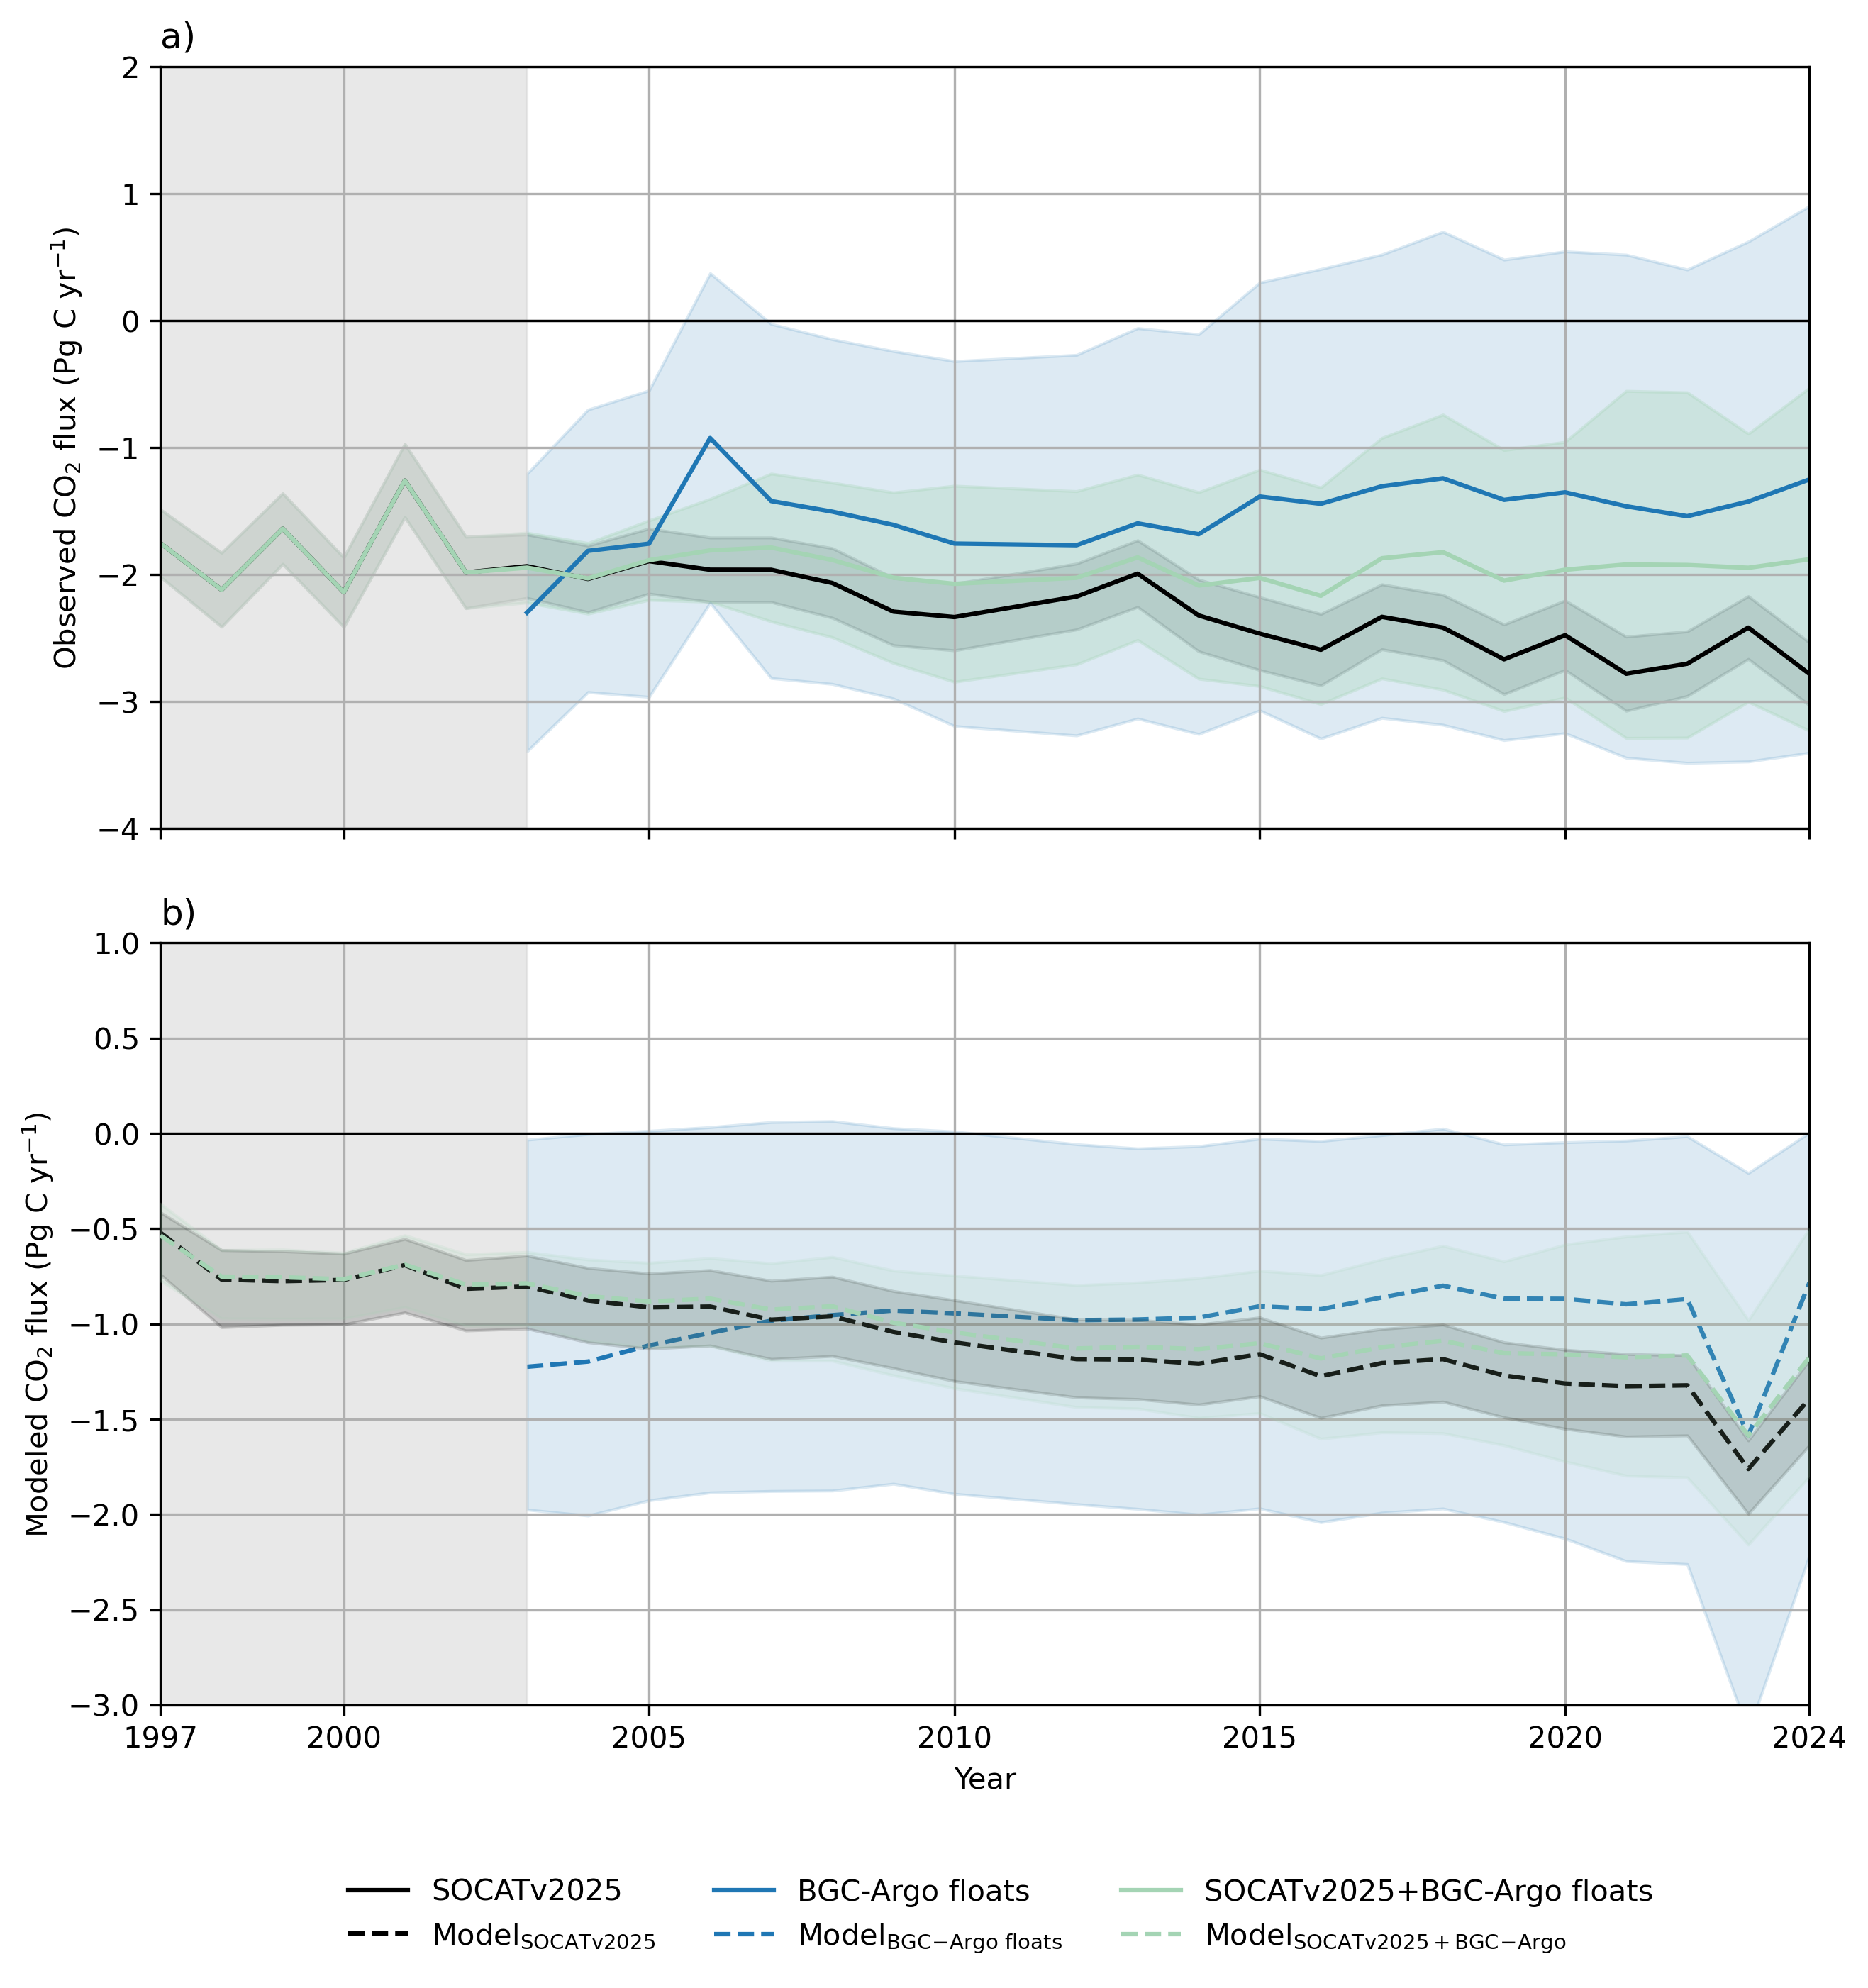

In [4]:
# =================
# 8) PLOTTING (Fig)
# =================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), dpi=300, sharex=True, gridspec_kw={'hspace': 0.15})

# Observations in Pg C/yr
line1, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_PgC_yr_fullarea'], 
                  label='SOCATv2025', c='k', zorder=2)
line3, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['Floats_PgC_yr_fullarea'], 
                  label='BGC-Argo floats', c='tab:blue', zorder=2)
line5, = ax1.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT+Floats_PgC_yr_fullarea'], 
                  label='SOCATv2025+BGC-Argo floats', c='#A4D4B4', zorder=2)

ax1.fill_between(yearly_flux_summary['year'], 
                 yearly_flux_summary['SOCAT_low_PgC_yr_fullarea'], 
                 yearly_flux_summary['SOCAT_high_PgC_yr_fullarea'], 
                 color='k', alpha=0.15, zorder=1)
ax1.fill_between(yearly_flux_summary['year'], 
                 yearly_flux_summary['Floats_low_PgC_yr_fullarea'], 
                 yearly_flux_summary['Floats_high_PgC_yr_fullarea'], 
                 color='tab:blue', alpha=0.15, zorder=1)
ax1.fill_between(yearly_flux_summary['year'], 
                 yearly_flux_summary['SOCAT+Floats_low_PgC_yr_fullarea'], 
                 yearly_flux_summary['SOCAT+Floats_high_PgC_yr_fullarea'], 
                 color='#A4D4B4', alpha=0.30, zorder=1)

ax1.set_ylabel(r'Observed CO$_2$ flux (Pg C yr$^{-1}$)')
ax1.set_xlim(1997, 2024)
ax1.set_ylim(-4, 2)
ax1.axhline(0, c='k', lw=0.8)
ax1.grid(True)
ax1.axvspan(1997, 2003, color='lightgray', alpha=0.5, zorder=1)

# Predictions in Pg C/yr
line2, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_predictions_PgC_yr_fullarea'], 
                  label=r'Model$_{\mathrm{SOCATv2025}}$', linestyle='--', c='k', zorder=2)
ax2.fill_between(yearly_flux_summary['year'], 
                 yearly_flux_summary['SOCAT_predictions_low_PgC_yr_fullarea'], 
                 yearly_flux_summary['SOCAT_predictions_high_PgC_yr_fullarea'], 
                 color='k', alpha=0.15, zorder=2, label='_nolegend_')
line4, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['FLOATS_predictions_PgC_yr_fullarea'], 
                  label=r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$', linestyle='--', c='tab:blue', zorder=1)
ax2.fill_between(yearly_flux_summary['year'], 
                 yearly_flux_summary['FLOATS_predictions_low_PgC_yr_fullarea'], 
                 yearly_flux_summary['FLOATS_predictions_high_PgC_yr_fullarea'], 
                 color='tab:blue', alpha=0.15, zorder=1, label='_nolegend_')
line6, = ax2.plot(yearly_flux_summary['year'], yearly_flux_summary['SOCAT_AND_FLOATS_predictions_PgC_yr_fullarea'], 
                  label=r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$', linestyle='--', c='#A4D4B4', zorder=3)
ax2.fill_between(yearly_flux_summary['year'], 
                 yearly_flux_summary['SOCAT_AND_FLOATS_predictions_low_PgC_yr_fullarea'], 
                 yearly_flux_summary['SOCAT_AND_FLOATS_predictions_high_PgC_yr_fullarea'], 
                 color='#A4D4B4', alpha=0.15, zorder=3, label='_nolegend_')

ax2.set_xlabel('Year')
ax2.set_ylabel(r'Modeled CO$_2$ flux (Pg C yr$^{-1}$)')
ax2.set_xlim(1997, 2024)
ax2.set_xticks([1997, 2000, 2005, 2010, 2015, 2020, 2024])
ax2.set_ylim(-3, 1)
ax2.axhline(0, c='k', lw=0.8)
ax2.grid(True)
ax2.axvspan(1997, 2003, color='lightgray', alpha=0.5, zorder=1)

# Labels + legend
ax1.text(0, 1.06, 'a)', transform=ax1.transAxes, fontsize=12, va='top', ha='left')
ax2.text(0, 1.06, 'b)', transform=ax2.transAxes, fontsize=12, va='top', ha='left')
handles = [line1, line2, line3, line4, line5, line6]
labels  = ['SOCATv2025', r'Model$_{\mathrm{SOCATv2025}}$', 'BGC-Argo floats', r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$', 'SOCATv2025+BGC-Argo floats', r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$']
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, fontsize=10, bbox_to_anchor=(0.52, -0.02))
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/figs/main_result_obs_vs_models.png", dpi=300, bbox_inches='tight')
plt.show()


## Code for presentation 

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

# ====== CONFIG ======
base_dir = Path("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/figs/presentation")
base_dir.mkdir(parents=True, exist_ok=True)

years = yearly_flux_summary['year']
span_start, span_end = 1997, 2003
x_min, x_max = 1997, 2024
xticks = [1997, 2000, 2005, 2010, 2015, 2020, 2024]

# Series definitions: name, column for central value, (low, high) columns, color, linestyle, zorder, label, fill_alpha
OBS_SERIES = [
    dict(key="socat_obs",   y="SOCAT_PgC_yr_fullarea",
         lo="SOCAT_low_PgC_yr_fullarea",   hi="SOCAT_high_PgC_yr_fullarea",
         color="k", ls="-", z=2, label="SOCATv2025", fill_alpha=0.15),
    dict(key="floats_obs",  y="Floats_PgC_yr_fullarea",
         lo="Floats_low_PgC_yr_fullarea",  hi="Floats_high_PgC_yr_fullarea",
         color="tab:blue", ls="-", z=2, label="BGC-Argo floats", fill_alpha=0.15),
    dict(key="combo_obs",   y="SOCAT+Floats_PgC_yr_fullarea",
         lo="SOCAT+Floats_low_PgC_yr_fullarea", hi="SOCAT+Floats_high_PgC_yr_fullarea",
         color="#A4D4B4", ls="-", z=2, label="SOCATv2025+BGC-Argo floats", fill_alpha=0.30),
]

PRED_SERIES = [
    dict(key="socat_pred",  y="SOCAT_predictions_PgC_yr_fullarea",
         lo=None, hi=None,
         color="k", ls="--", z=1, label=r"Model$_{\mathrm{SOCATv2025}}$", fill_alpha=None),
    dict(key="floats_pred", y="FLOATS_predictions_PgC_yr_fullarea",
         lo="FLOATS_predictions_low_PgC_yr_fullarea", hi="FLOATS_predictions_high_PgC_yr_fullarea",
         color="tab:blue", ls="--", z=2, label=r"Model$_{\mathrm{BGC\!-\!Argo\ floats}}$", fill_alpha=0.15),
    dict(key="combo_pred",  y="SOCAT_AND_FLOATS_predictions_PgC_yr_fullarea",
         lo="SOCAT_AND_FLOATS_predictions_low_PgC_yr_fullarea", hi="SOCAT_AND_FLOATS_predictions_high_PgC_yr_fullarea",
         color="#A4D4B4", ls="--", z=3, label=r"Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$", fill_alpha=0.15),
]

# Which subsets to plot (in order) and filenames
JOBS = [
    # Observations (3 figs)
    dict(kind="obs",  include=["socat_obs"],                             fname="obs_1_SOCAT_only.png"),
    dict(kind="obs",  include=["socat_obs", "floats_obs"],               fname="obs_2_SOCAT_and_FLOATS.png"),
    dict(kind="obs",  include=["socat_obs", "floats_obs", "combo_obs"],  fname="obs_3_SOCAT_FLOATS_COMBINED.png"),
    # Predictions (3 figs)
    dict(kind="pred", include=["socat_pred"],                             fname="pred_4_SOCAT_only.png"),
    dict(kind="pred", include=["socat_pred", "floats_pred"],              fname="pred_5_SOCAT_and_FLOATS.png"),
    dict(kind="pred", include=["socat_pred", "floats_pred", "combo_pred"],fname="pred_6_SOCAT_FLOATS_COMBINED.png"),
]

def series_lookup(kind):
    return {d["key"]: d for d in (OBS_SERIES if kind == "obs" else PRED_SERIES)}

def y_lims(kind):
    return (-4, 2) if kind == "obs" else (-4, 2)

def y_label(kind):
    return r'Observed CO$_2$ flux (Pg C yr$^{-1}$)' if kind == "obs" else r'Modeled CO$_2$ flux (Pg C yr$^{-1}$)'

for job in JOBS:
    kind = job["kind"]
    subset = job["include"]
    ser_map = series_lookup(kind)

    fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi=300)

    handles, labels = [], []

    for key in subset:
        s = ser_map[key]
        y = yearly_flux_summary[s["y"]]
        (line,) = ax.plot(
            years, y,
            linestyle=s["ls"], c=s["color"], zorder=s["z"],
            label=s["label"]
        )
        handles.append(line)
        labels.append(s["label"])

        # Confidence band if available
        if s["lo"] is not None and s["hi"] is not None and s["fill_alpha"]:
            lo = yearly_flux_summary[s["lo"]]
            hi = yearly_flux_summary[s["hi"]]
            ax.fill_between(
                years, lo, hi, color=s["color"], alpha=s["fill_alpha"], zorder=s["z"]
            )

    # Axes cosmetics
    ax.set_xlim(x_min, x_max)
    ax.set_xticks(xticks)
    ax.set_ylim(*y_lims(kind))
    ax.axhline(0, c='k', lw=0.8)
    ax.grid(True)
    ax.axvspan(span_start, span_end, color='lightgray', alpha=0.5, zorder=1)
    ax.set_xlabel("Year")
    ax.set_ylabel(y_label(kind))

    # Legend (only what we plotted)
    ax.legend(handles, labels, loc='upper right', frameon=True, fontsize=10)

    # Save
    outpath = base_dir / f"main_result_singlepanel_{job['fname']}"
    fig.tight_layout()
    fig.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.close(fig)

print("Saved 6 figures to:", base_dir)


Saved 6 figures to: /home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/figs/presentation


### Below is for Table 2

In [6]:
mean_uptake

FLOATS_predictions_PgC_yr_fullarea                  -0.984931
FLOATS_predictions_high_PgC_yr_fullarea             -0.021509
FLOATS_predictions_low_PgC_yr_fullarea              -2.057038
Floats_PgC_yr_fullarea                              -1.521481
Floats_high_PgC_yr_fullarea                          0.101447
Floats_low_PgC_yr_fullarea                          -3.144409
SOCAT+Floats_PgC_yr_fullarea                        -1.951718
SOCAT+Floats_high_PgC_yr_fullarea                   -1.148342
SOCAT+Floats_low_PgC_yr_fullarea                    -2.755094
SOCAT_AND_FLOATS_predictions_PgC_yr_fullarea        -1.074127
SOCAT_AND_FLOATS_predictions_high_PgC_yr_fullarea   -0.679241
SOCAT_AND_FLOATS_predictions_low_PgC_yr_fullarea    -1.468935
SOCAT_PgC_yr_fullarea                               -2.314383
SOCAT_high_PgC_yr_fullarea                          -2.049938
SOCAT_low_PgC_yr_fullarea                           -2.578827
SOCAT_predictions_PgC_yr_fullarea                   -1.160701
SOCAT_pr

### Below is for Table 3

In [7]:
from scipy.stats import linregress
import pandas as pd
import numpy as np

# Filter relevant columns
pgc_cols = [c for c in yearly_flux_summary.columns if c.endswith('_PgC_yr_fullarea')]
df = yearly_flux_summary.query("2003 <= year <= 2024").copy()

# Helper: get slopes + uncertainty from _low/_high
def get_slopes_with_uncertainty(df, cols):
    results = []
    for col in cols:
        if any(suffix in col for suffix in ['_low', '_high']):
            continue  # skip bounds, handle them with base name
        base_name = col.replace('_PgC_yr_fullarea', '')
        
        # find low/high variants if they exist
        low_col = f"{base_name}_low_PgC_yr_fullarea"
        high_col = f"{base_name}_high_PgC_yr_fullarea"
        
        # main slope
        y = df[col].dropna()
        x = df.loc[y.index, 'year']
        slope, intercept, r, p, stderr = linregress(x, y)
        
        # uncertainty from bounds
        unc = np.nan
        if low_col in df.columns and high_col in df.columns:
            # slope for low bound
            y_low = df[low_col].dropna()
            x_low = df.loc[y_low.index, 'year']
            slope_low, *_ = linregress(x_low, y_low)
            
            # slope for high bound
            y_high = df[high_col].dropna()
            x_high = df.loc[y_high.index, 'year']
            slope_high, *_ = linregress(x_high, y_high)
            
            # ± as half-range
            unc = abs(slope_high - slope_low) / 2
        
        results.append({
            'Dataset': base_name,
            'Slope (Pg C yr⁻²)': slope,
            '±': unc if not np.isnan(unc) else np.nan,
            'p-value': p,
            'Trend': 'Intensifying' if slope < 0 else 'Weakening',
            'Significant': p < 0.05
        })
    return pd.DataFrame(results).sort_values('Slope (Pg C yr⁻²)')

slopes_fullarea = get_slopes_with_uncertainty(df, pgc_cols)

# Round for presentation
slopes_fullarea['Slope (Pg C yr⁻²)'] = slopes_fullarea['Slope (Pg C yr⁻²)'].round(2)
slopes_fullarea['±'] = slopes_fullarea['±'].round(2)
slopes_fullarea['p-value'] = slopes_fullarea['p-value'].round(2)

print(slopes_fullarea)


                        Dataset  Slope (Pg C yr⁻²)     ±  p-value  \
1                         SOCAT              -0.04  0.00     0.00   
0             SOCAT_predictions              -0.03  0.00     0.00   
3  SOCAT_AND_FLOATS_predictions              -0.02  0.02     0.00   
5                  SOCAT+Floats              -0.00  0.05     0.81   
2            FLOATS_predictions               0.01  0.01     0.23   
4                        Floats               0.02  0.05     0.03   

          Trend  Significant  
1  Intensifying         True  
0  Intensifying         True  
3  Intensifying         True  
5  Intensifying        False  
2     Weakening        False  
4     Weakening         True  


## Add interior storage from Gruber et al. (2019)

In [8]:
import xarray as xr
interior_anth = xr.load_dataset("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Gruber2019_1994-2007_v20220608/dcant_Gruber2019_1994-2007_v20220608.nc")
interior_vol = xr.load_dataset("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Gruber2019_1994-2007_v20220608/volume_Gruber2019_1994-2007_v20220608.nc")

In [9]:
# ================================
# Gruber ΔCant vs. uptake (+ CIs)
# ================================
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ----- inputs expected to exist -----
# interior_anth['dcant']  (mol m^-3)
# interior_vol['volume']  (m^3)
# yearly_flux_summary: yearly_flux_summary with *_PgC_yr_fullarea columns
# ------------------------------------

# ---- 1) Integrate Gruber ΔCant to Pg C/yr (south of 35°S) ----
dc = interior_anth['dcant']
vol = interior_vol['volume']
YEARS_GRUBER = 13  # 1994–2007 inclusive

def integrate_storage(dcant, volume, lat_cut=-35.0, years=YEARS_GRUBER):
    dcant, volume = xr.align(dcant, volume, join='inner')
    so = dcant['latitude'] <= lat_cut
    mol_total = (dcant.where(so) * volume.where(so)).sum(skipna=True)     # mol
    PgC_total = (mol_total.values * 12.01) / 1e15                         # Pg C
    return float(PgC_total / years)                                       # Pg C/yr

S35 = integrate_storage(dc, vol, lat_cut=-35.0)
print(f"Gruber ΔCant storage south of 35°S (1994–2007): {S35:.3f} Pg C/yr")

# ---- 2) Windowed means (with _low/_high where available) ----
def window_mean(df, col, y0, y1):
    if col not in df.columns:
        return np.nan
    sl = df[(df['year'] >= y0) & (df['year'] <= y1)]
    return float(sl[col].mean(skipna=True)) if len(sl) else np.nan

SUF = '_PgC_yr_fullarea'

# Base series and the matching low/high names in `yearly_flux_summary`
series_specs = [
    # name_in_yearly_flux_summary, window_start, window_end
    ('SOCAT',                        1997, 2007),
    ('SOCAT_predictions',            1997, 2007),
    ('Floats',                       2003, 2007),
    ('FLOATS_predictions',           2003, 2007),
    ('SOCAT+Floats',                 1997, 2007),
    ('SOCAT_AND_FLOATS_predictions', 1997, 2007),
]

rows = []
for base, y0, y1 in series_specs:
    mean_col = base + SUF
    low_col  = base.replace('predictions', 'predictions_low') + SUF if 'predictions' in base else base + '_low'  + SUF
    high_col = base.replace('predictions', 'predictions_high')+ SUF if 'predictions' in base else base + '_high' + SUF

    # some series don't have low/high; that's OK
    m   = window_mean(yearly_flux_summary, mean_col, y0, y1)
    lo  = window_mean(yearly_flux_summary, low_col,  y0, y1) if low_col  in yearly_flux_summary.columns else np.nan
    hi  = window_mean(yearly_flux_summary, high_col, y0, y1) if high_col in yearly_flux_summary.columns else np.nan

    rows.append({
        'series': base,
        'window': f'{y0}–{y1}',
        'mean_PgCyr': m,
        'low_PgCyr':  lo,
        'high_PgCyr': hi,
        'ratio_to_storage35': (m / S35) if np.isfinite(m) else np.nan
    })

# Add the Gruber storage row (no error bars)
rows.append({
    'series': 'Gruber_storage',
    'window': '1994–2007',
    'mean_PgCyr': S35,
    'low_PgCyr':  np.nan,
    'high_PgCyr': np.nan,
    'ratio_to_storage35': 1.0
})

windowed_means = pd.DataFrame(rows)

# ---- 3) Build plotting frame & asymmetric errors on magnitudes ----
# We plot absolute magnitudes as positive bars for readability.
plot_df = windowed_means.copy()
plot_df['label'] = plot_df['series'].map({
    'SOCAT': 'SOCATv2025',
    'SOCAT_predictions': r'Model$_{\mathrm{SOCATv2025}}$',
    'Floats': 'BGC-Argo floats',
    'FLOATS_predictions': r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    'SOCAT+Floats': 'SOCATv2025+BGC-Argo floats',
    'SOCAT_AND_FLOATS_predictions': r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Gruber_storage': 'Interior storage'
}).fillna(plot_df['series'])

# custom order to match your main figure
custom_order = [
    'SOCATv2025',
    'BGC-Argo floats',
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025}}$',
    r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Interior storage'
]
plot_df['order'] = plot_df['label'].apply(lambda x: custom_order.index(x) if x in custom_order else len(custom_order))
plot_df = plot_df.sort_values('order').reset_index(drop=True)

# magnitudes (positive)
def mag(x): 
    return np.abs(x) if np.isfinite(x) else np.nan

plot_df['mag_mean'] = plot_df['mean_PgCyr'].apply(mag)
plot_df['mag_low']  = plot_df['low_PgCyr'].apply(mag)
plot_df['mag_high'] = plot_df['high_PgCyr'].apply(mag)

# asymmetric x-errors around the magnitude:
# left error = mean_mag - high_mag (toward smaller magnitude; "high" is less negative)
# right error = low_mag - mean_mag  (toward larger magnitude; "low" is more negative)
left_err  = (plot_df['mag_mean'] - plot_df['mag_high']).clip(lower=0).fillna(0.0)
right_err = (plot_df['mag_low']  - plot_df['mag_mean']).clip(lower=0).fillna(0.0)
plot_df['xerr_left']  = left_err.values
plot_df['xerr_right'] = right_err.values

# ---- 4) Colors by window, with SOCAT+Floats forced to SOCAT color ----
window_colors = {
    '1997–2007': '#13505B',   # SOCAT-era (your figure)
    '2003–2007': '#A8DCD1',   # Floats-era
    '1994–2007': '#F7A9A8',   # Gruber ΔCant
}
colors = plot_df['window'].map(window_colors).fillna('#000000')

socat_color = window_colors['1997–2007']
labels_to_match_socat = [
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$'
]
colors[plot_df['label'].isin(labels_to_match_socat)] = socat_color


Gruber ΔCant storage south of 35°S (1994–2007): 0.615 Pg C/yr


## Add interior storage from Muller et al. (2023)

In [10]:
import xarray as xr

# --- Load Müller et al. (2023) products ---
anth_path = "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Muller2023/dcant_emlr_cstar_mueller_94-04-14.nc"
vol_path  = "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Muller2023/volume_mask_emlr_cstar_mueller_94-04-14.nc"

interior_anth = xr.load_dataset(anth_path)
interior_vol  = xr.load_dataset(vol_path)

In [11]:
interior_anth.period

<xarray.DataArray 'period' (period: 2)> Size: 88B
array(['1994 - 2004', '2004 - 2014'], dtype='<U11')
Coordinates:
  * period   (period) <U11 88B '1994 - 2004' '2004 - 2014'

Müller interior storage south of 35°S (Pg C/yr) by period:
1994 - 2004    1.049254
2004 - 2014    0.763873
Name: PgC_yr, dtype: float64


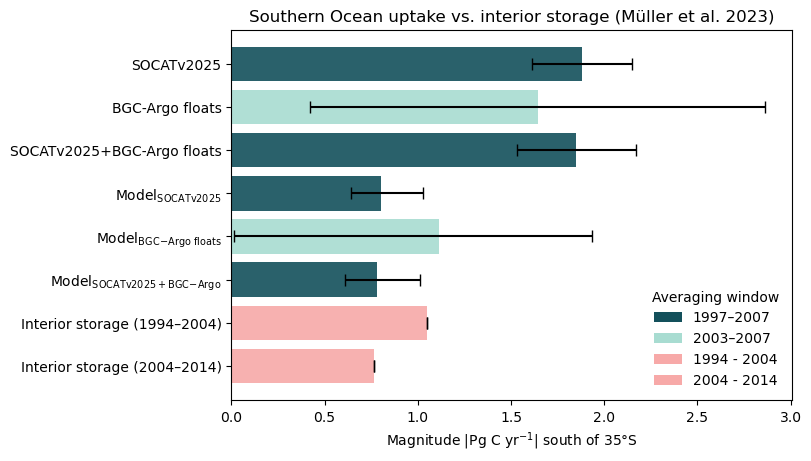

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Select "standard case" slice (fallback to first if not present) ---
def select_standard_case(da):
    confs = list(map(str, da["MLR_configuration"].values))
    masks = list(map(str, da["MLR_basin_mask"].values))
    # Try to find something that looks like the standard case
    # Prefer exact label "Standard case", else any label containing "Standard",
    # else just take the first available.
    conf_label = None
    for target in ["Standard case", "standard case"]:
        if target in confs:
            conf_label = target
            break
    if conf_label is None:
        conf_label = next((c for c in confs if "Standard" in c or "standard" in c), confs[0])

    # For basin mask, prefer '3' (SO merged), else first
    mask_label = '3' if '3' in masks else masks[0]
    return da.sel(MLR_configuration=conf_label, MLR_basin_mask=mask_label)

dc_mueller = select_standard_case(interior_anth["dcant"])  # dims: period, depth, lat, lon
vol3d = interior_vol[[v for v in interior_vol.data_vars][0]]  # pick the (only) 3-D volume var

# --- Unit conversions (μmol kg^-1 decade^-1 → Pg C yr^-1 over volume) ---
RHO = 1030.0        # kg m^-3 (μmol/kg → μmol/m^3)
UMOL_TO_MOL = 1e-6  # μmol → mol
DECADE_YEARS = 10.0
M_C = 12.0          # g mol^-1
G_PER_PG = 1e15     # g in 1 Pg

def integrate_storage_mueller_per_year(dcant_umolkg_per_decade, volume_m3, lat_cut=-35.0, lat_name="lat"):
    """
    Integrate Müller ΔCant tendency (per-year) over the 3D ocean south of lat_cut.
    Returns a pandas.Series indexed by 'period' with Pg C yr^-1 values.
    """
    # Convert to mol m^-3 per decade, then to per year
    dc_molm3_per_year = dcant_umolkg_per_decade * UMOL_TO_MOL * RHO / DECADE_YEARS

    # Align to volume grid and mask south of 35°S
    dc_molm3_per_year, volume_m3 = xr.align(dc_molm3_per_year, volume_m3, join="inner")
    so = dc_molm3_per_year[lat_name] <= lat_cut

    # Integrate over depth/lat/lon for each period (mol yr^-1)
    mol_yr = (dc_molm3_per_year.where(so) * volume_m3.where(so)).sum(dim=("depth", "lat", "lon"), skipna=True)

    # Convert to Pg C yr^-1
    pgc_yr = mol_yr * M_C / G_PER_PG
    periods = list(map(str, dc_molm3_per_year["period"].values))
    return pd.Series([float(pgc_yr.sel(period=p)) for p in periods], index=periods, name="PgC_yr")

S35_by_period = integrate_storage_mueller_per_year(dc_mueller, vol3d, lat_cut=-35.0)
print("Müller interior storage south of 35°S (Pg C/yr) by period:")
print(S35_by_period)

# Use the mean of the two period storages as a single reference (for ratios)
S35_ref = float(np.nanmean(S35_by_period.values))

# ---- 2) Windowed means (with _low/_high where available) ----
def window_mean(df, col, y0, y1):
    if col not in df.columns:
        return np.nan
    sl = df[(df['year'] >= y0) & (df['year'] <= y1)]
    return float(sl[col].mean(skipna=True)) if len(sl) else np.nan

SUF = '_PgC_yr_fullarea'

# Base series and the matching low/high names in `yearly_flux_summary`
series_specs = [
    # name_in_yearly_flux_summary, window_start, window_end
    ('SOCAT',                        1997, 2007),
    ('SOCAT_predictions',            1997, 2007),
    ('Floats',                       2003, 2007),
    ('FLOATS_predictions',           2003, 2007),
    ('SOCAT+Floats',                 1997, 2007),
    ('SOCAT_AND_FLOATS_predictions', 1997, 2007),
]

rows = []
for base, y0, y1 in series_specs:
    mean_col = base + SUF
    if 'predictions' in base:
        low_col  = base.replace('predictions', 'predictions_low')  + SUF
        high_col = base.replace('predictions', 'predictions_high') + SUF
    else:
        low_col  = base + '_low'  + SUF
        high_col = base + '_high' + SUF

    m  = window_mean(yearly_flux_summary, mean_col, y0, y1)
    lo = window_mean(yearly_flux_summary, low_col,  y0, y1) if low_col  in yearly_flux_summary.columns else np.nan
    hi = window_mean(yearly_flux_summary, high_col, y0, y1) if high_col in yearly_flux_summary.columns else np.nan

    rows.append({
        'series': base,
        'window': f'{y0}–{y1}',
        'mean_PgCyr': m,
        'low_PgCyr':  lo,
        'high_PgCyr': hi,
        'ratio_to_storage35': (m / S35_ref) if np.isfinite(m) and np.isfinite(S35_ref) else np.nan
    })

# Append Müller storage rows (no error bars)
for per, val in S35_by_period.items():
    rows.append({
        'series': f'Mueller_storage_{per.replace(" ", "")}',
        'window': per,                 # e.g., '1994 - 2004' or '2004 - 2014'
        'mean_PgCyr': val,
        'low_PgCyr':  np.nan,
        'high_PgCyr': np.nan,
        'ratio_to_storage35': 1.0
    })

windowed_means = pd.DataFrame(rows)

# ---- 3) Build plotting frame & asymmetric errors on magnitudes ----
plot_df = windowed_means.copy()
plot_df['label'] = plot_df['series'].map({
    'SOCAT': 'SOCATv2025',
    'SOCAT_predictions': r'Model$_{\mathrm{SOCATv2025}}$',
    'Floats': 'BGC-Argo floats',
    'FLOATS_predictions': r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    'SOCAT+Floats': 'SOCATv2025+BGC-Argo floats',
    'SOCAT_AND_FLOATS_predictions': r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Mueller_storage_1994-2004': 'Interior storage (1994–2004)',
    'Mueller_storage_2004-2014': 'Interior storage (2004–2014)',
}).fillna(plot_df['series'])

# custom order to match your main figure (extend with the two storage bars)
custom_order = [
    'SOCATv2025',
    'BGC-Argo floats',
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025}}$',
    r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Interior storage (1994–2004)',
    'Interior storage (2004–2014)',
]
plot_df['order'] = plot_df['label'].apply(lambda x: custom_order.index(x) if x in custom_order else len(custom_order))
plot_df = plot_df.sort_values('order').reset_index(drop=True)

# magnitudes (positive) and asymmetric x-errors
def mag(x): 
    return np.abs(x) if np.isfinite(x) else np.nan

plot_df['mag_mean'] = plot_df['mean_PgCyr'].apply(mag)
plot_df['mag_low']  = plot_df['low_PgCyr'].apply(mag)
plot_df['mag_high'] = plot_df['high_PgCyr'].apply(mag)

left_err  = (plot_df['mag_mean'] - plot_df['mag_high']).clip(lower=0).fillna(0.0)  # toward smaller magnitude
right_err = (plot_df['mag_low']  - plot_df['mag_mean']).clip(lower=0).fillna(0.0)  # toward larger magnitude
xerr = np.vstack([left_err.values, right_err.values])  # shape (2, N)

# ---- 4) Colors by window, ensuring SOCAT+Floats matches SOCAT color ----
window_colors = {
    '1997–2007': '#13505B',   # SOCAT-era
    '2003–2007': '#A8DCD1',   # Floats-era
    '1994 - 2004': '#F7A9A8', # Müller ΔCant period 1
    '2004 - 2014': '#F7A9A8', # Müller ΔCant period 2 (same family)
}
colors = plot_df['window'].map(window_colors).fillna('#000000')

socat_color = window_colors['1997–2007']
labels_to_match_socat = [
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$'
]
colors[plot_df['label'].isin(labels_to_match_socat)] = socat_color

# ---- 5) Plot (horizontal bars with asymmetric xerr) ----
fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
y = np.arange(len(plot_df))
ax.barh(y, plot_df['mag_mean'].values, xerr=xerr, color=colors.values, alpha=0.9, capsize=4)
ax.set_yticks(y, plot_df['label'].values)
ax.set_xlabel('Magnitude |Pg C yr$^{-1}$| south of 35°S')
ax.invert_yaxis()

# Legend keyed by "window" color
legend_keys = []
for w, c in window_colors.items():
    legend_keys.append(Patch(facecolor=c, edgecolor='none', label=w))
ax.legend(handles=legend_keys, title='Averaging window', loc='lower right', frameon=False)

ax.set_title('Southern Ocean uptake vs. interior storage (Müller et al. 2023)')
plt.show()


## Add inverse fluxes from Hauck et al. (2023)

In [13]:
import numpy as np
import pandas as pd
import xarray as xr

# === Load ===
path = "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/224_GCP2021inversionsforRECCAP21x1version1120211122/GCP2021_inversions_for_RECCAP2_1x1_version1_1_20211122.nc"
ds = xr.open_dataset(path, decode_times=False)

# === Decode time (days since 2000-01-01) ===
base_time = pd.Timestamp("2000-01-01")
ds["time"] = base_time + pd.to_timedelta(ds["time"].values, unit="D")

# === Settings ===
VAR = "ocean_flux_NOT_adjusted"   # units: PgC m^-2 yr^-1
LAT_CUT = -35.0
start_date, end_date = "2003-01-01", "2007-12-31"

# === Variable ===
flux = ds[VAR]

# Drop only true sentinels; keep valid data as-is (no “filling”)
# 9.96921e36-type and any absurd magnitude
bad = (~np.isfinite(flux)) | (np.abs(flux) > 1e20)
flux = flux.where(~bad)

# === 1°×1° cell area (m²) using spherical cap formula ===
# A_cell = R^2 * dlon * (sin(phi+0.5°) - sin(phi-0.5°))
R = 6.371e6
dlon = np.deg2rad(1.0)
phi_n = np.deg2rad(flux.latitude + 0.5)
phi_s = np.deg2rad(flux.latitude - 0.5)
cell_area_lat = (R**2) * dlon * (np.sin(phi_n) - np.sin(phi_s))  # shape: (lat,)
cell_area = cell_area_lat.broadcast_like(flux.isel(time=0, ninversions=0))  # (lat, lon)

# === Convert to PgC yr^-1 per cell ===
# (PgC m^-2 yr^-1) * (m^2) = PgC yr^-1  ✅
flux_cell_PgCyr = flux * cell_area

# === Southern Ocean mask and space-integration ===
mask_SO_2d = (flux.latitude <= LAT_CUT).broadcast_like(cell_area)
flux_SO_total = flux_cell_PgCyr.where(mask_SO_2d).sum(dim=("latitude", "longitude"), skipna=True)  # per inversion, per time

# === Select window and average over time ===
flux_SO_sel = flux_SO_total.sel(time=slice(start_date, end_date))
mean_per_inv = flux_SO_sel.mean(dim="time", skipna=True)  # PgC/yr for each inversion

# === Ensemble stats ===
ensemble_mean = float(mean_per_inv.mean(dim="ninversions", skipna=True).values)
ensemble_std  = float(mean_per_inv.std(dim="ninversions",  skipna=True).values)

print(f"Southern Ocean mean flux ({start_date} to {end_date}): {ensemble_mean:.3f} ± {ensemble_std:.3f} PgC/yr")

# Optional: per-inversion breakdown
per_inv = mean_per_inv.to_series()
per_inv.index = [f"inv_{i}" for i in range(len(per_inv))]
print("\nPer-inversion totals (PgC/yr) over 2003–2007:")
print(per_inv.round(3))


Southern Ocean mean flux (2003-01-01 to 2007-12-31): -0.750 ± 0.358 PgC/yr

Per-inversion totals (PgC/yr) over 2003–2007:
inv_0   -0.826
inv_1   -0.914
inv_2   -1.156
inv_3   -0.847
inv_4    0.000
inv_5   -0.754
dtype: float64


In [14]:
ds.time

<xarray.DataArray 'time' (time: 372)> Size: 3kB
array(['1990-01-01T00:00:00.000000000', '1990-02-01T00:00:00.000000000',
       '1990-03-01T00:00:00.000000000', ..., '2020-10-01T00:00:00.000000000',
       '2020-11-01T00:00:00.000000000', '2020-12-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 1990-01-01 1990-02-01 ... 2020-12-01

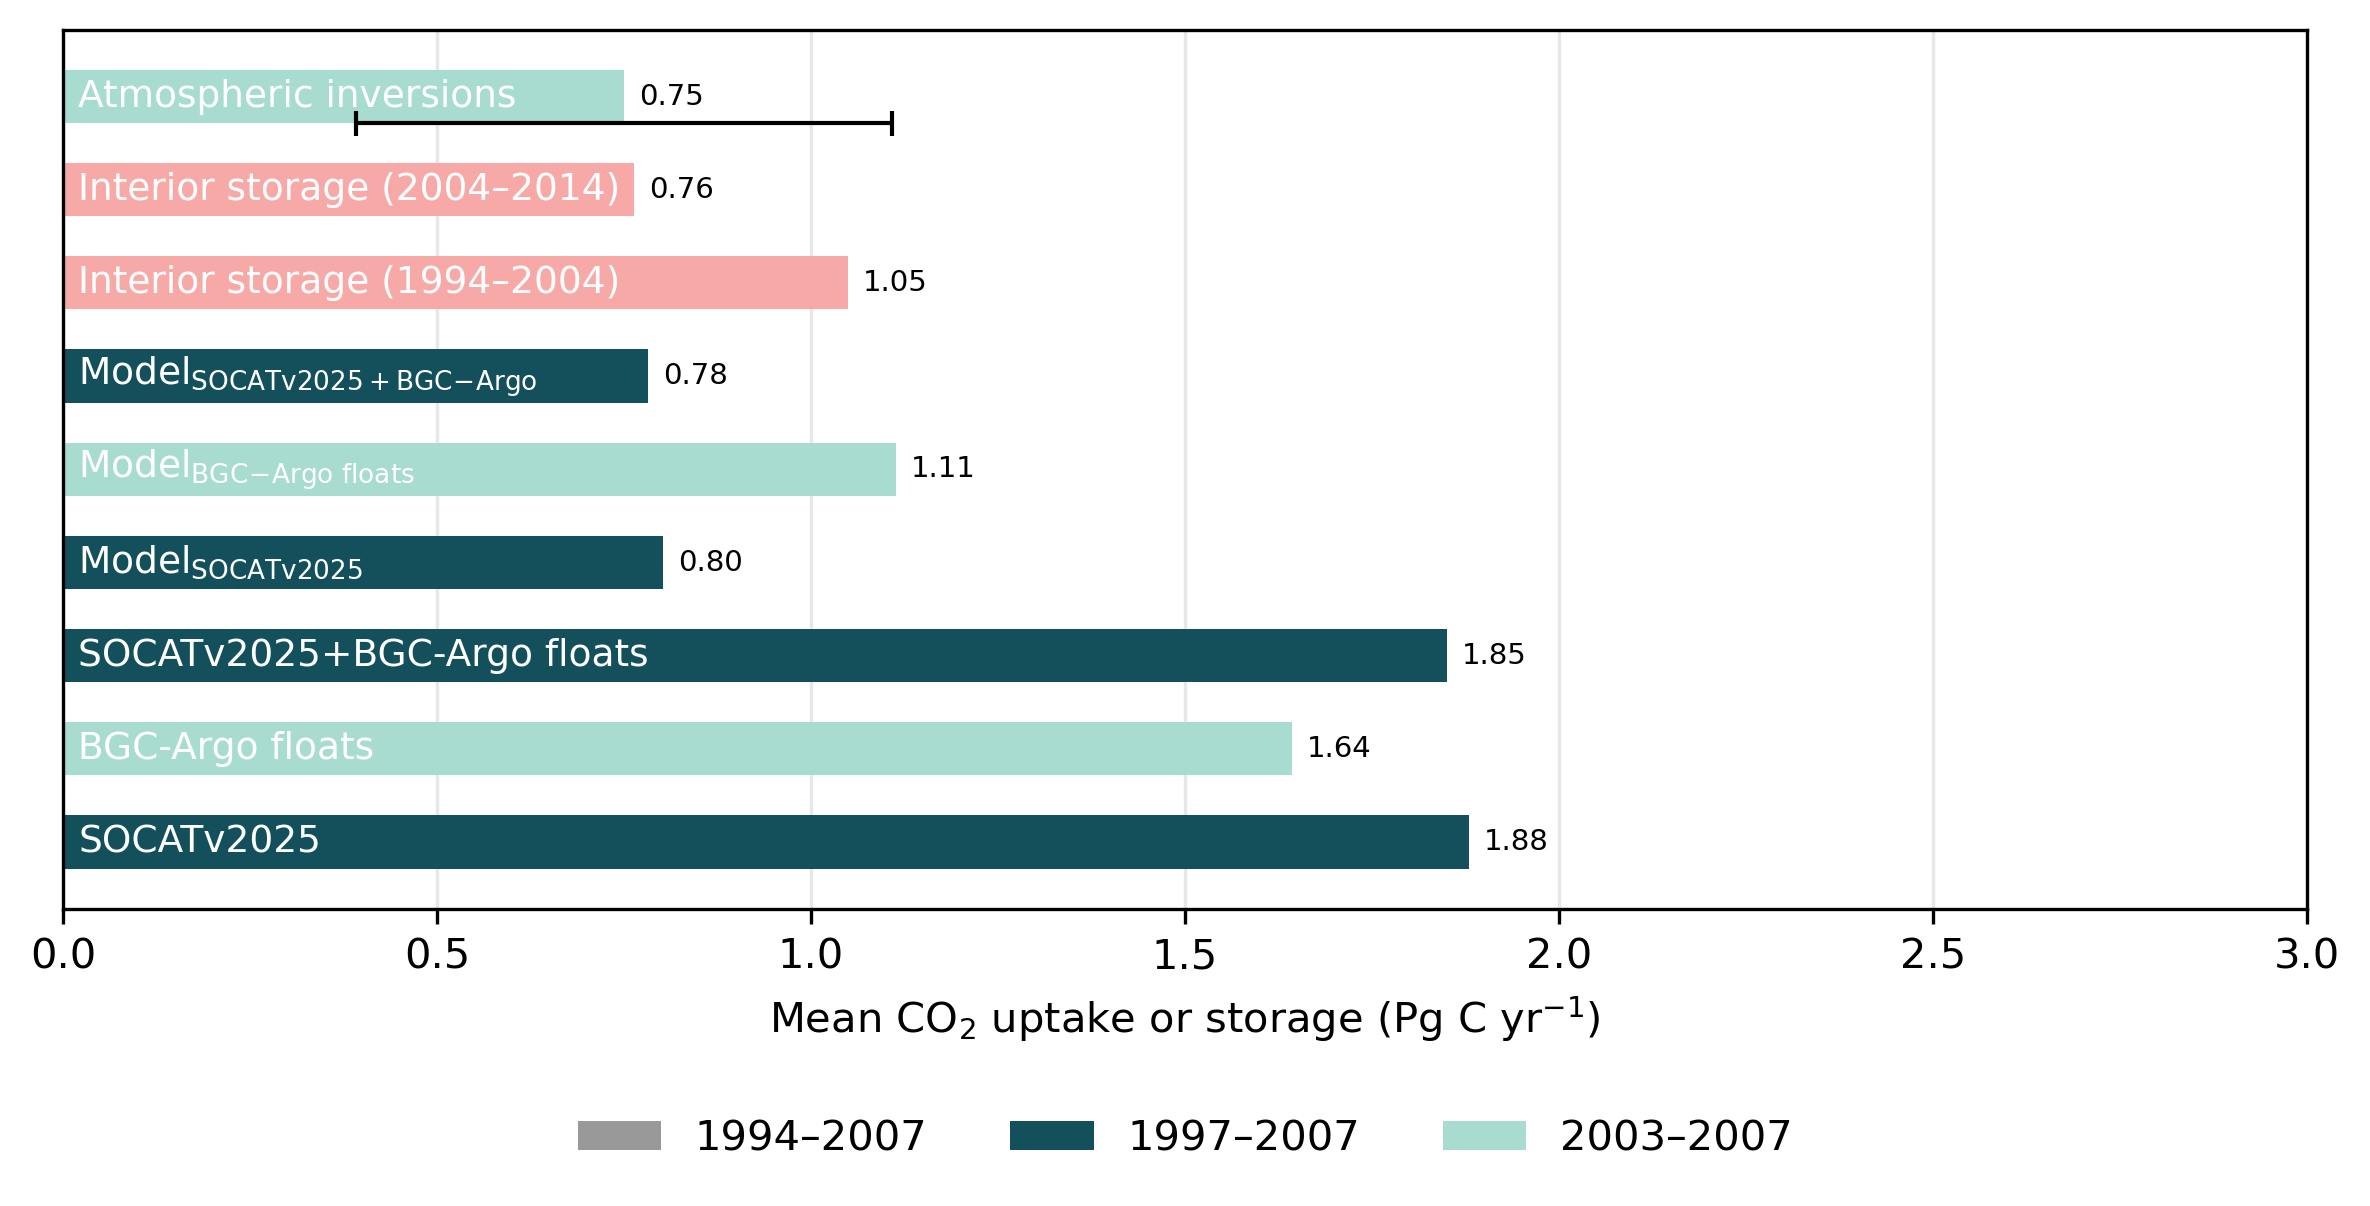

In [15]:
# === Add Atmospheric Inversions row (2003–2007, SO ≤35°S) and plot ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- sanity: require prior results & dataframe ---
try:
    _ = ensemble_mean
    _ = ensemble_std
    _ = plot_df
except NameError as e:
    raise NameError("This cell expects 'ensemble_mean', 'ensemble_std', and 'plot_df' "
                    "to already exist from previous steps.") from e

# optional: window color map (only if not already defined)
if "window_colors" not in globals():
    window_colors = {
        "1994–2007": "#8c8c8c",
        "1997–2007": "#66c2a5",
        "2003–2007": "#4C78A8",
    }

# === Build new row from previous calc variables ===
inv_mean = float(ensemble_mean)   # signed Pg C/yr (negative = uptake)
inv_std  = float(ensemble_std)    # Pg C/yr

# Convert signed mean±std to magnitude with asymmetric errors
mag_mean  = abs(inv_mean)
bounds    = [abs(inv_mean - inv_std), abs(inv_mean + inv_std)]
mag_low   = min(bounds)
mag_high  = max(bounds)
xerr_left  = mag_mean - mag_low
xerr_right = mag_high - mag_mean

new_row = {
    "label": "Atmospheric inversions",   # <- as requested
    "window": "2003–2007",
    "mag_mean": mag_mean,
    "mag_low":  mag_low,
    "mag_high": mag_high,
    "xerr_left":  xerr_left,
    "xerr_right": xerr_right,
}

# Append if not already present (by label); else update values
if "label" in plot_df.columns and (plot_df["label"] == new_row["label"]).any():
    plot_df.loc[plot_df["label"] == new_row["label"], list(new_row.keys())] = list(new_row.values())
else:
    plot_df = pd.concat([plot_df, pd.DataFrame([new_row])], ignore_index=True)

# Build colors per row from 'window'
colors = plot_df["window"].map(window_colors).fillna("#999999").tolist()

# --- Keep only ONE "Atmospheric inversions" row (prefer 2003–2007), normalize label ---
rank = {'1994–2007': 1, '1997–2007': 2, '2003–2007': 3}
mask = plot_df['label'].str.startswith('Atmospheric inversions', na=False)

if mask.sum() > 1:
    sub = plot_df.loc[mask].copy()
    sub['_rank'] = sub['window'].map(rank).fillna(0)
    keep_idx = sub.sort_values('_rank').index[-1]  # highest rank wins (2003–2007 > 1997–2007 > 1994–2007)
    drop_idx = plot_df.index[mask].difference([keep_idx])
    plot_df = plot_df.drop(index=drop_idx).reset_index(drop=True)

# Normalize the label text to exactly "Atmospheric inversions"
plot_df.loc[plot_df['label'].str.startswith('Atmospheric inversions', na=False), 'label'] = 'Atmospheric inversions'

# Rebuild bar colors from window
colors = plot_df['window'].map(window_colors).fillna('#999999').tolist()


# ---- 5) Plot: horizontal bars + asymmetric error bars ----
bar_height = 0.20
spacing    = 0.35
ypos       = np.arange(len(plot_df)) * spacing

fig, ax = plt.subplots(figsize=(8, 4), dpi=300)

bars = ax.barh(
    ypos, plot_df['mag_mean'],
    color=colors, height=bar_height, zorder=2
)

# If you have "Interior" rows to hide errors for, keep this; otherwise it's harmless
if "label" in plot_df.columns:
    is_gruber = plot_df['label'].str.contains('Interior', regex=False)
    plot_df.loc[is_gruber, ['xerr_left', 'xerr_right']] = np.nan

# shift error bars to bottom edge of each bar
err_ypos = ypos - (bar_height / 2)

ax.errorbar(
    plot_df['mag_mean'], err_ypos,
    xerr=[plot_df['xerr_left'], plot_df['xerr_right']],
    fmt='none', ecolor='k', elinewidth=1, capsize=3, zorder=3
)

ax.set_xlabel("Mean CO$_2$ uptake or storage (Pg C yr$^{-1}$)")
ax.set_yticks([])             # no y tick labels
ax.grid(alpha=0.3, axis='x', zorder=1)

# series labels inside bars (white)
for bar, label in zip(bars, plot_df['label']):
    ax.text(0.02, bar.get_y() + bar.get_height()/2, label,
            ha='left', va='center', fontsize=9, color='white', zorder=4)

# numeric values at the bar ends
for bar, val in zip(bars, plot_df['mag_mean']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", ha='left', va='center', fontsize=7, color='black', zorder=4)

# set x-limit explicitly as in your code
ax.set_xlim(0, 3)

# legend (below) in custom order
legend_order = ['1994–2007', '1997–2007', '2003–2007']
legend_handles = [Patch(facecolor=window_colors.get(w, "#999999"), edgecolor='none', label=w)
                  for w in legend_order]

fig.legend(handles=legend_handles,
           labels=legend_order,
           loc='lower center',
           frameon=False,
           ncol=len(legend_order),
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


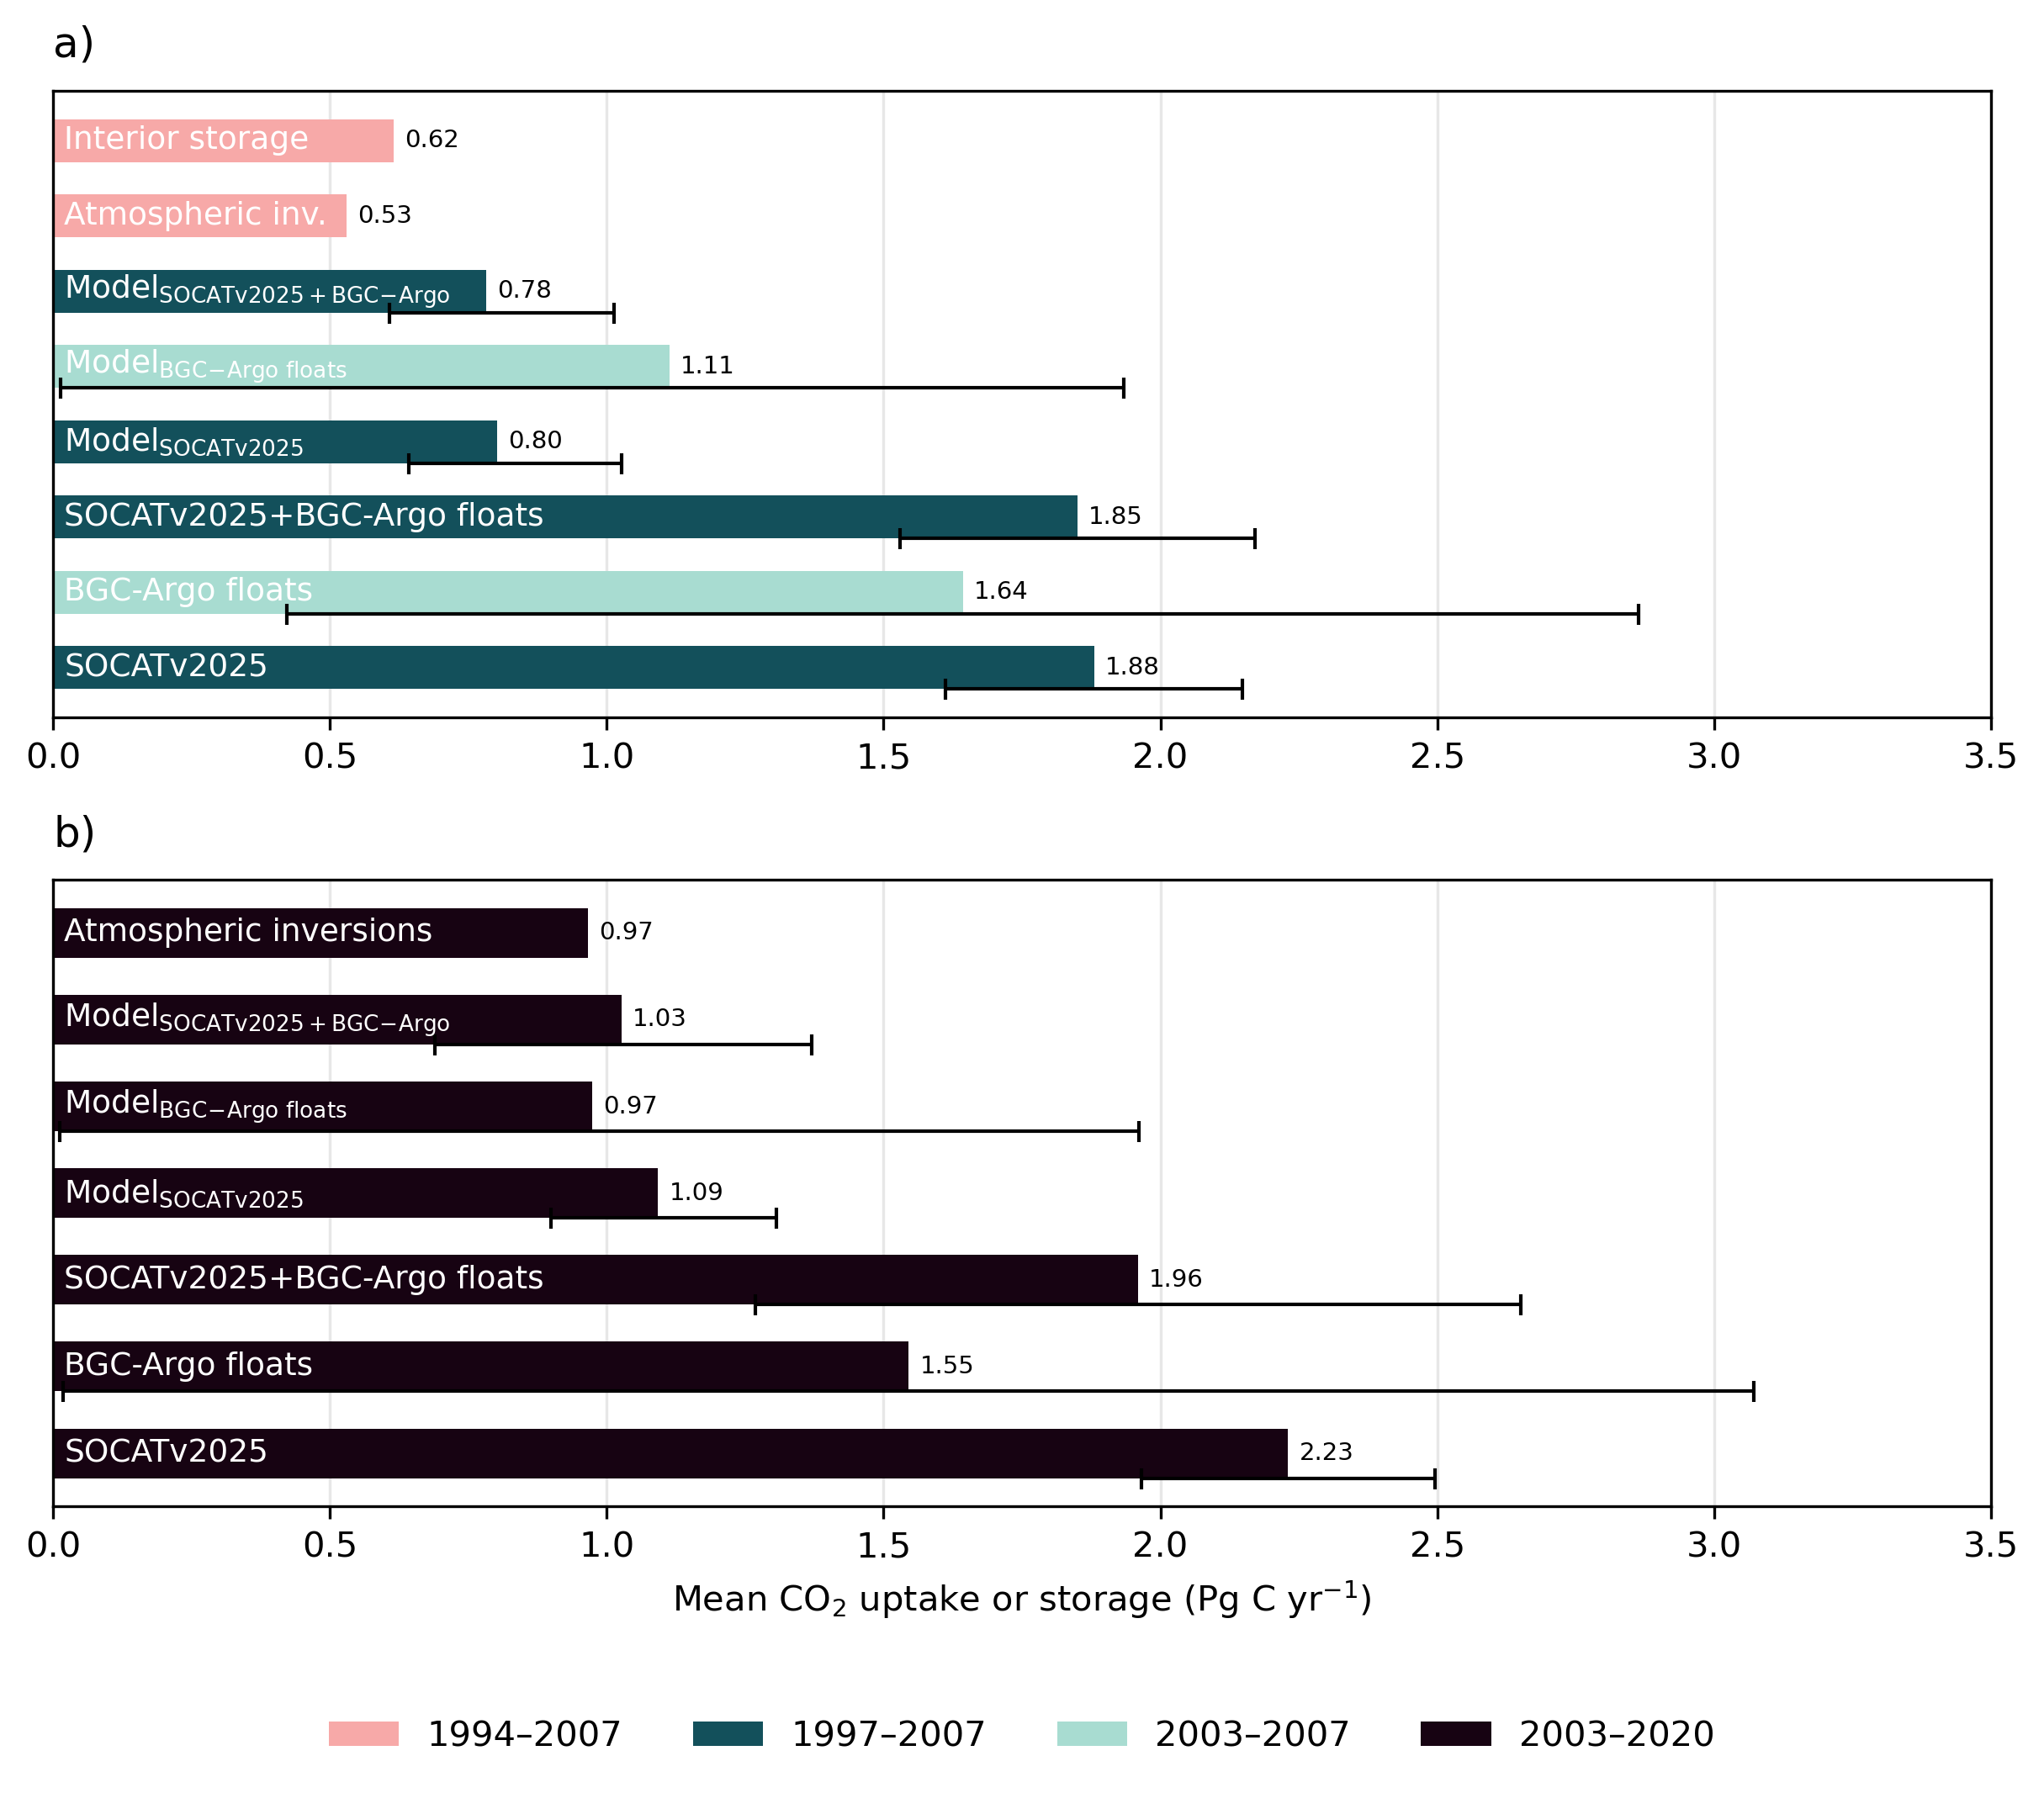

In [16]:
# ===========================
# 2-PANEL SUMMARY BAR FIGURE
# ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- window colors (extend your map) ---
window_colors = {
    '1994–2007': '#F7A9A8',  # Gruber / long inversions
    '1997–2007': '#13505B',  # SOCAT-era
    '2003–2007': '#A8DCD1',  # floats-era
    '2003–2020': '#170312',  # extended period
}

# --- label mapping (matches your style) ---
label_map = {
    'SOCAT': 'SOCATv2025',
    'Floats': 'BGC-Argo floats',
    'SOCAT+Floats': 'SOCATv2025+BGC-Argo floats',
    'SOCAT_predictions': r'Model$_{\mathrm{SOCATv2025}}$',
    'FLOATS_predictions': r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    'SOCAT_AND_FLOATS_predictions': r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Gruber_storage': 'Interior storage',
    'Atmospheric inversions': 'Atmospheric inversions',
}

# --- helper: mean over year window from yearly_flux_summary ---
SUF = '_PgC_yr_fullarea'

def window_mean(df, col, y0, y1):
    if col not in df.columns:
        return np.nan
    sl = df[(df['year'] >= y0) & (df['year'] <= y1)]
    return float(sl[col].mean(skipna=True)) if len(sl) else np.nan

def series_stats(base, y0, y1, yfs):
    """Return mag mean and asym errors for a base series using *_low/*_high when available.
       Temporary hack: if SOCAT+Floats only has _low, mirror it around the mean to fake _high."""
    mean_col = base + SUF

    if 'predictions' in base and 'FLOATS' in base:
        low_col  = base + '_low'  + SUF
        high_col = base + '_high' + SUF
    elif 'SOCAT_AND_FLOATS_predictions' in base:  # <-- special case
        low_col  = base + '_low' + SUF
        high_col = None
    elif 'predictions' in base:
        low_col  = base + '_low'  + SUF
        high_col = base + '_high' + SUF
        if low_col not in yfs.columns or high_col not in yfs.columns:
            low_col = high_col = None
    else:
        low_col  = base + '_low'  + SUF
        high_col = base + '_high' + SUF
        if low_col not in yfs.columns or high_col not in yfs.columns:
            low_col = high_col = None

    m  = window_mean(yfs, mean_col, y0, y1)
    lo = window_mean(yfs, low_col,  y0, y1) if low_col  else np.nan
    hi = window_mean(yfs, high_col, y0, y1) if high_col else np.nan

    # --- temp mirror hack ---
    if 'SOCAT_AND_FLOATS_predictions' in base and np.isfinite(lo) and not np.isfinite(hi):
        hi = 2*m - lo   # mirror around mean

    # convert signed uptake to magnitude + asymmetric x-errors
    mag_mean  = abs(m) if np.isfinite(m) else np.nan
    mag_low   = abs(lo) if np.isfinite(lo) else np.nan
    mag_high  = abs(hi) if np.isfinite(hi) else np.nan

    xerr_left  = (mag_mean - mag_high) if np.isfinite(mag_high) else 0.0
    xerr_right = (mag_low  - mag_mean) if np.isfinite(mag_low)  else 0.0
    xerr_left  = max(xerr_left, 0.0)
    xerr_right = max(xerr_right, 0.0)

    return mag_mean, xerr_left, xerr_right


# --- Atmospheric inversions integration helper (≤35°S) ---
def atm_inversions_mean_std(ds, start_date, end_date,
                            var='ocean_flux_NOT_adjusted', lat_cut=-35.0):
    # decode time if needed
    if np.issubdtype(ds['time'].dtype, np.number):
        base_time = pd.Timestamp("2000-01-01")
        time = base_time + pd.to_timedelta(ds['time'].values, unit="D")
    else:
        time = pd.to_datetime(ds['time'].values)

    flux = ds[var]
    # mask impossible fill values
    bad = (~np.isfinite(flux)) | (np.abs(flux) > 1e20)
    flux = flux.where(~bad)

    # 1°x1° cell areas (m²)
    R = 6.371e6
    dlon = np.deg2rad(1.0)
    phi_n = np.deg2rad(flux.latitude + 0.5)
    phi_s = np.deg2rad(flux.latitude - 0.5)
    cell_area_lat = (R**2) * dlon * (np.sin(phi_n) - np.sin(phi_s))
    cell_area = cell_area_lat.broadcast_like(flux.isel(time=0, ninversions=0))

    # integrate over SO (≤ lat_cut) → PgC/yr per time/inversion
    mask_SO = (flux.latitude <= lat_cut).broadcast_like(cell_area)
    flux_cell_PgCyr = flux * cell_area
    total_SO = flux_cell_PgCyr.where(mask_SO).sum(dim=('latitude', 'longitude'), skipna=True)

    # select window
    t = pd.DatetimeIndex(time)
    ix = (t >= pd.to_datetime(start_date)) & (t <= pd.to_datetime(end_date))
    total_SO = total_SO.sel(time=total_SO['time'][ix])

    mean_per_inv = total_SO.mean(dim='time', skipna=True)
    ensemble_mean = float(mean_per_inv.mean(dim='ninversions', skipna=True).values)
    ensemble_std  = float(mean_per_inv.std(dim='ninversions',  skipna=True).values)
    return ensemble_mean, ensemble_std

# --- (optional) compute S35 if not already defined from your earlier block ---
if 'S35' not in globals():
    # expects interior_anth['dcant'] and interior_vol['volume'] already loaded (like in your code)
    dc = interior_anth['dcant']; vol = interior_vol['volume']
    dc, vol = xr.align(dc, vol, join='inner')
    so = dc['latitude'] <= -35.0
    mol_total = (dc.where(so) * vol.where(so)).sum(skipna=True)     # mol
    S35 = float((mol_total.values * 12.01) / 1e15 / 13.0)           # Pg C/yr over 1994–2007

# --- build plot tables for panels ---
def build_plot_df(specs, window_label, include_gruber=False, add_atm_inv=None):
    """
    specs: list of tuples (base_name, y0, y1) for yearly_flux_summary
    add_atm_inv: tuple (start_date, end_date) or None
    """
    rows = []
    for base, y0, y1 in specs:
        m, xl, xr = series_stats(base, y0, y1, yearly_flux_summary)
        rows.append({
            'label': label_map.get(base, base),
            'window': f'{y0}–{y1}',
            'mag_mean': m,
            'xerr_left': xl,
            'xerr_right': xr,
        })

    if include_gruber:
        rows.append({
            'label': label_map['Gruber_storage'],
            'window': '1994–2007',
            'mag_mean': abs(S35),
            'xerr_left': np.nan,
            'xerr_right': np.nan,
        })

    if add_atm_inv is not None:
        start_date, end_date = add_atm_inv
        inv_mean, inv_std = atm_inversions_mean_std(ds, start_date, end_date)
        # convert to magnitude with ±std → asymmetric around |mean|
        mag_mean = abs(inv_mean)
        bounds = [abs(inv_mean - inv_std), abs(inv_mean + inv_std)]
        mag_low, mag_high = min(bounds), max(bounds)
        rows.append({
            'label': label_map['Atmospheric inversions'],
            'window': f"{pd.to_datetime(start_date).year}–{pd.to_datetime(end_date).year}",
            'mag_mean': mag_mean,
            'xerr_left': max(mag_mean - mag_high, 0.0),
            'xerr_right': max(mag_low - mag_mean, 0.0),
        })

    df = pd.DataFrame(rows)

    # order to match your style
    order = [
        'SOCATv2025',
        'BGC-Argo floats',
        'SOCATv2025+BGC-Argo floats',
        r'Model$_{\mathrm{SOCATv2025}}$',
        r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
        r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
        'Atmospheric inversions',
        'Interior storage'
    ]
    df['order'] = df['label'].apply(lambda x: order.index(x) if x in order else len(order))
    df = df.sort_values('order').reset_index(drop=True)
    return df

# --- updated helper: no per-axes legend; optional xlabel; skip errors for specific labels ---
def plot_bar_panel(ax, plot_df, xlim=(0, 3.5), set_xlabel=False, label_subs=None):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    bar_height = 0.20
    spacing    = 0.35
    ypos       = np.arange(len(plot_df)) * spacing

    colors = plot_df['window'].map(window_colors).fillna('#999999').tolist()
    bars = ax.barh(ypos, plot_df['mag_mean'], color=colors, height=bar_height, zorder=2)

    # --- draw error bars EXCEPT for Gruber & Atm. inversions ---
    skip_err = plot_df['label'].isin(['Interior storage', 'Atmospheric inversions'])
    err_mask = (~skip_err) & np.isfinite(plot_df['mag_mean'])
    err_ypos = (ypos - (bar_height/2))[err_mask]
    xerr = np.vstack([
        plot_df.loc[err_mask, 'xerr_left'].fillna(0.0).values,
        plot_df.loc[err_mask, 'xerr_right'].fillna(0.0).values
    ])
    ax.errorbar(plot_df.loc[err_mask, 'mag_mean'], err_ypos,
                xerr=xerr, fmt='none', ecolor='k', elinewidth=1, capsize=3, zorder=3)

    # labels inside bars (apply optional substitutions)
    for bar, label in zip(bars, plot_df['label']):
        disp = (label_subs or {}).get(label, label)
        ax.text(0.02, bar.get_y() + bar.get_height()/2, disp,
                ha='left', va='center', fontsize=9, color='white', zorder=4)

    # numeric values at bar ends
    for bar, val in zip(bars, plot_df['mag_mean']):
        if np.isfinite(val):
            ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                    f"{val:.2f}", ha='left', va='center', fontsize=7, color='black', zorder=4)

    ax.set_xlim(*xlim)
    ax.set_yticks([])
    if set_xlabel:
        ax.set_xlabel("Mean CO$_2$ uptake or storage (Pg C yr$^{-1}$)")
    ax.grid(alpha=0.3, axis='x', zorder=1)



# -----------------
# Panel (a) spec
# -----------------
spec_a = [
    ('SOCAT',                        1997, 2007),
    ('Floats',                       2003, 2007),
    ('SOCAT+Floats',                 1997, 2007),
    ('SOCAT_predictions',            1997, 2007),
    ('FLOATS_predictions',           2003, 2007),
    ('SOCAT_AND_FLOATS_predictions', 1997, 2007),
]
plot_a = build_plot_df(
    specs=spec_a,
    window_label=None,
    include_gruber=True,
    add_atm_inv=('1994-01-01', '2007-12-31')  # Atmospheric inversions 1994–2007
)

# -----------------
# Panel (b) spec
# -----------------
spec_b = [
    ('SOCAT',                        2003, 2020),
    ('Floats',                       2003, 2020),
    ('SOCAT+Floats',                 2003, 2020),
    ('SOCAT_predictions',            2003, 2020),
    ('FLOATS_predictions',           2003, 2020),
    ('SOCAT_AND_FLOATS_predictions', 2003, 2020),
]
plot_b = build_plot_df(
    specs=spec_b,
    window_label=None,
    include_gruber=False,                           # no Gruber in panel (b)
    add_atm_inv=('2003-01-01', '2020-12-31')        # Atmospheric inversions 2003–2020
)

# -----------------
# Draw two-row figure (a) and (b)
# -----------------
xlim = (0, 3.5)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.2, 7.2), dpi=300, constrained_layout=False, sharex=False)

# panel (a): no x-label here, shorten just this panel
plot_bar_panel(
    ax1, plot_a, xlim=xlim, set_xlabel=False,
    label_subs={'Atmospheric inversions': 'Atmospheric inv.'}
)
ax1.text(0.0, 1.04, 'a)', transform=ax1.transAxes, fontsize=12, va='bottom', ha='left')

# panel (b): x-label only here, keep full label
plot_bar_panel(ax2, plot_b, xlim=xlim, set_xlabel=True)
ax2.text(0.0, 1.04, 'b)', transform=ax2.transAxes, fontsize=12, va='bottom', ha='left')

# ---- combined legend below both panels ----
# Collect the union of window labels present across both panels, in a nice order.
legend_order = ['1994–2007', '1997–2007', '2003–2007', '2003–2020']
present = [w for w in legend_order if w in set(plot_a['window']).union(set(plot_b['window']))]
legend_handles = [Patch(facecolor=window_colors[w], edgecolor='none', label=w) for w in present]

# Tight layout with extra bottom margin reserved for the legend
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles=legend_handles, labels=present,
           loc='lower center', ncol=len(present), frameon=False, bbox_to_anchor=(0.5, 0.01))

# optional: save
fig.savefig("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/figs/inversion_fluxes_summary_bars_two_panel.png",
             dpi=300, bbox_inches='tight')
plt.show()


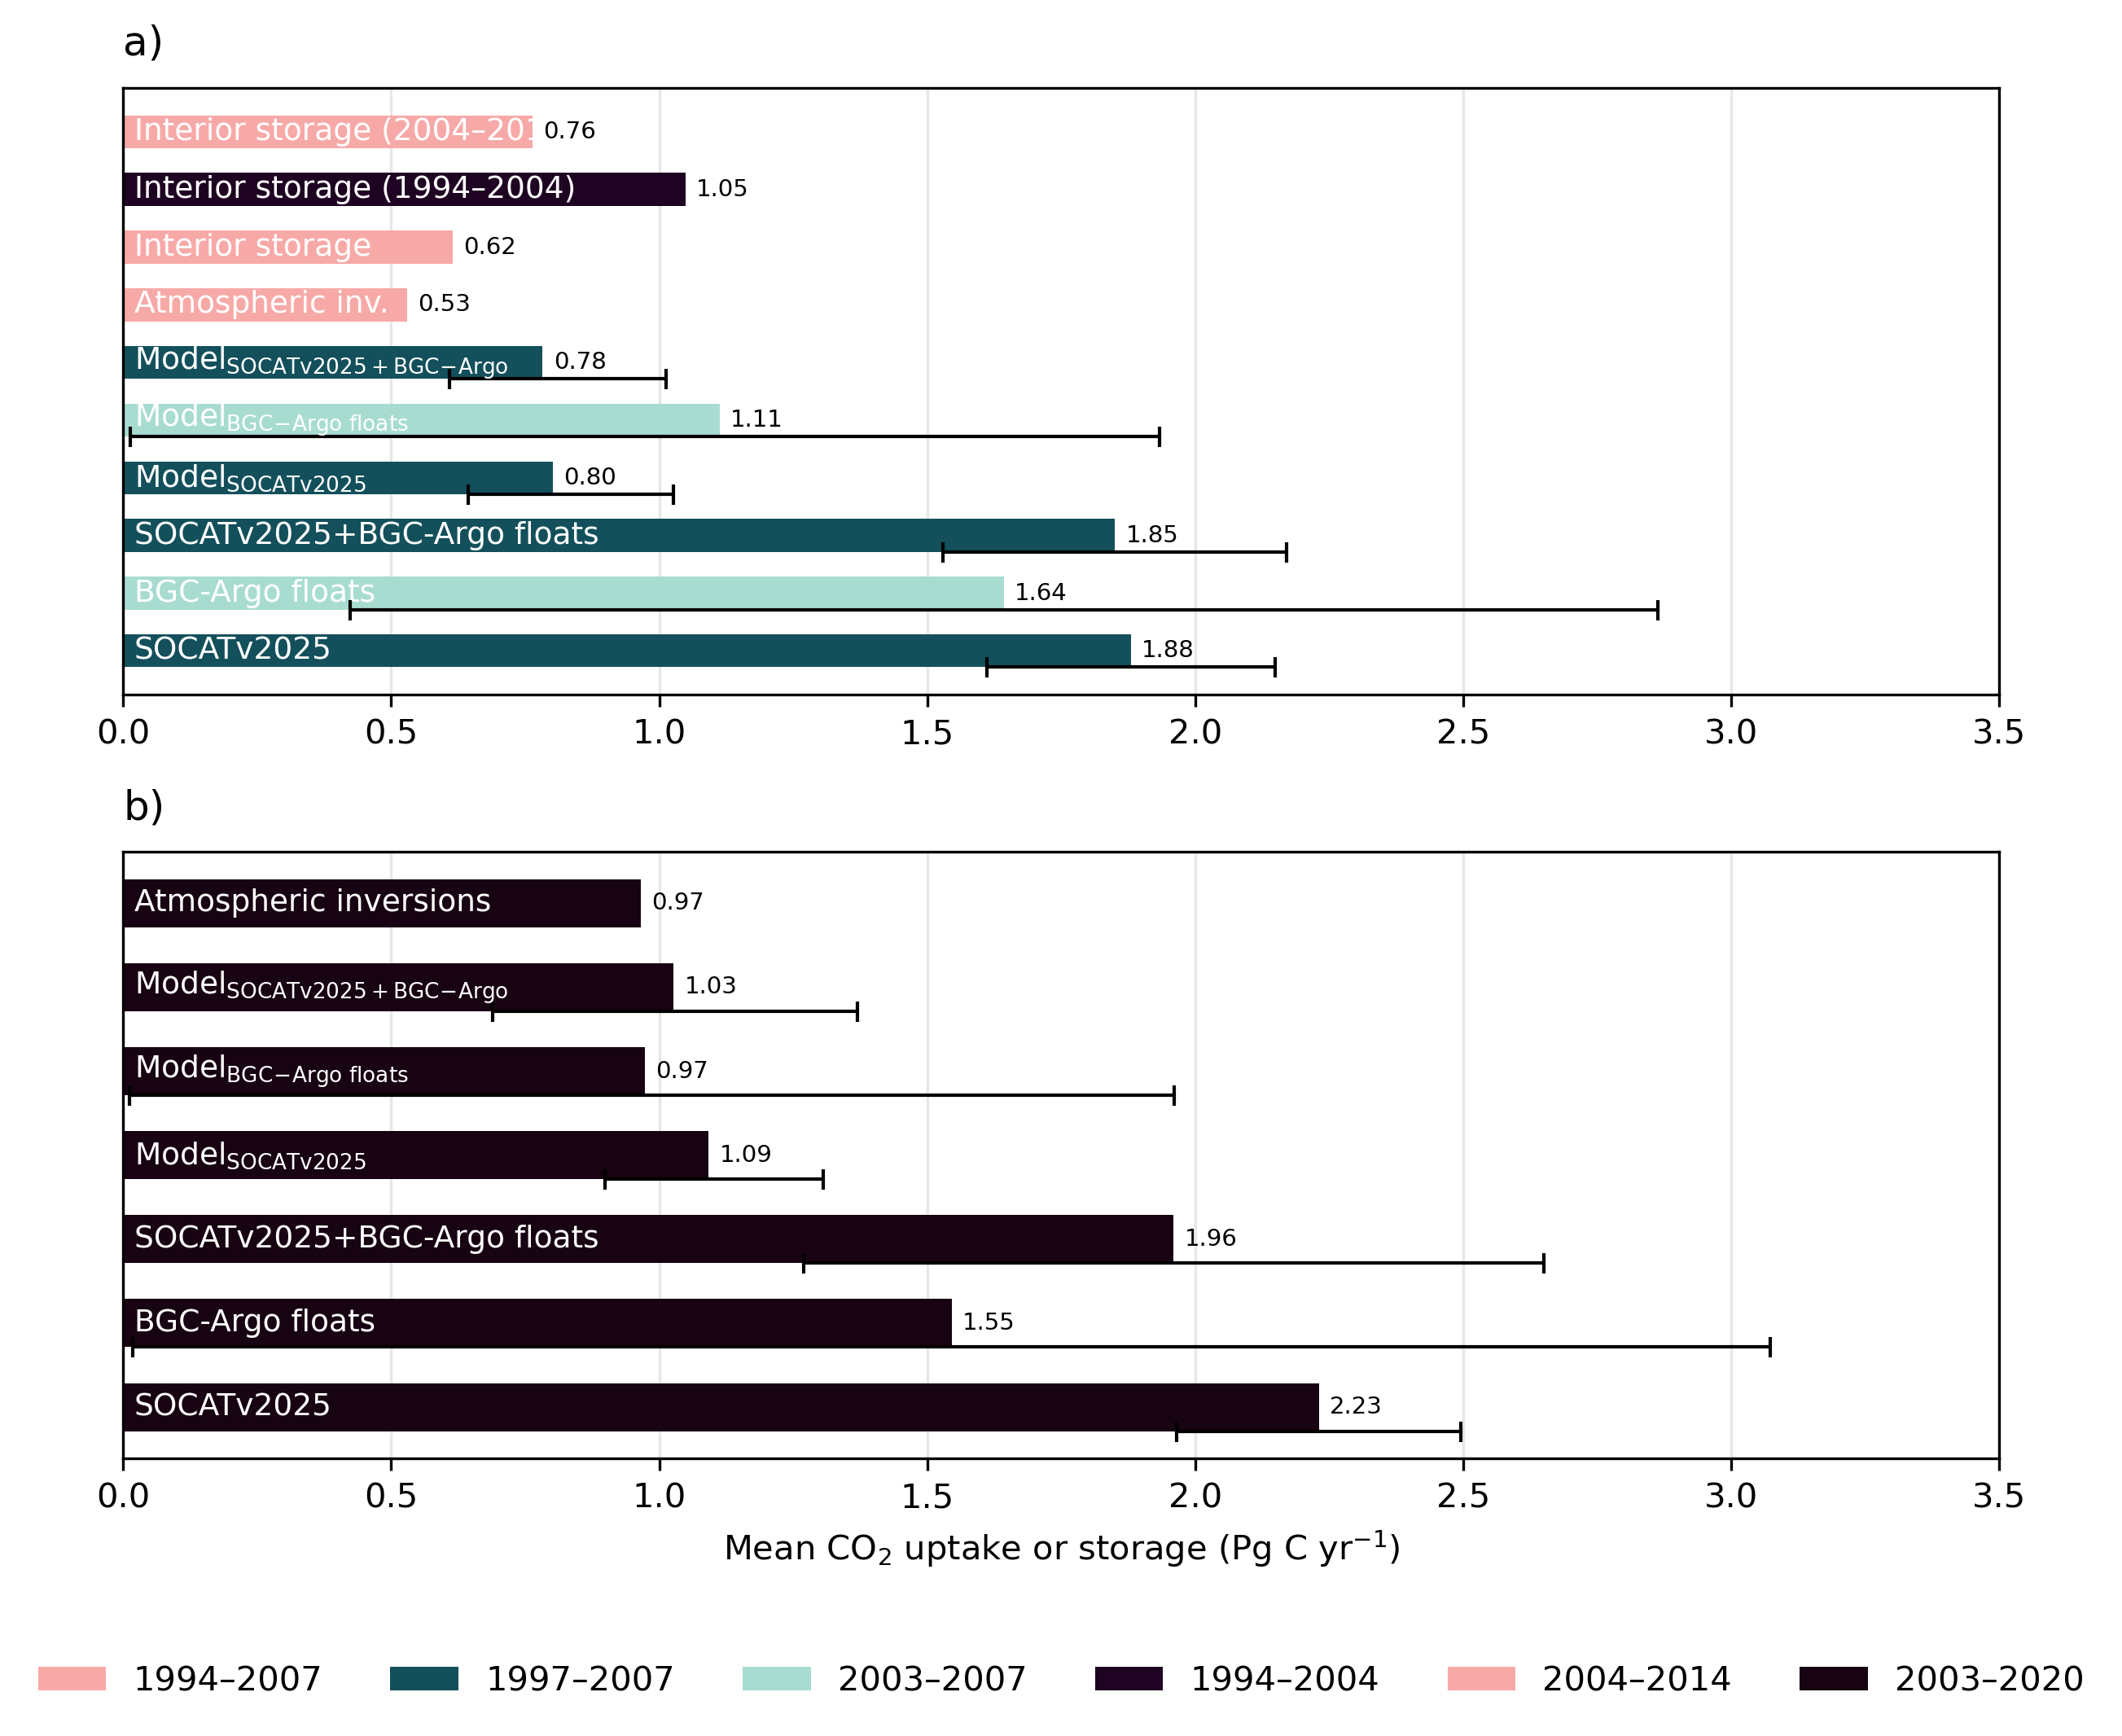

In [17]:
# ===========================
# 2-PANEL SUMMARY BAR FIGURE
# (with Müller et al. 2023 storage added to Panel a)
# ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- window colors (extend your map) ---
window_colors = {
    '1994–2007': '#F7A9A8',  # Gruber / long inversions
    '1997–2007': '#13505B',  # SOCAT-era
    '2003–2007': '#A8DCD1',  # floats-era
    '2003–2020': '#170312',  # extended period
    '1994–2004': '#1F0322',  # Müller period 1 (same family)
    '2004–2014': '#F7A9A8',  # Müller period 2 (same family)
}

# --- label mapping (matches your style) ---
label_map = {
    'SOCAT': 'SOCATv2025',
    'Floats': 'BGC-Argo floats',
    'SOCAT+Floats': 'SOCATv2025+BGC-Argo floats',
    'SOCAT_predictions': r'Model$_{\mathrm{SOCATv2025}}$',
    'FLOATS_predictions': r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    'SOCAT_AND_FLOATS_predictions': r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Gruber_storage': 'Interior storage',
    'Atmospheric inversions': 'Atmospheric inversions',
}

# --- helper: mean over year window from yearly_flux_summary ---
SUF = '_PgC_yr_fullarea'

def window_mean(df, col, y0, y1):
    if col not in df.columns:
        return np.nan
    sl = df[(df['year'] >= y0) & (df['year'] <= y1)]
    return float(sl[col].mean(skipna=True)) if len(sl) else np.nan

def series_stats(base, y0, y1, yfs):
    """Return mag mean and asym errors for a base series using *_low/*_high when available.
       Temporary hack: if SOCAT+Floats only has _low, mirror it around the mean to fake _high."""
    mean_col = base + SUF

    if 'predictions' in base and 'FLOATS' in base:
        low_col  = base + '_low'  + SUF
        high_col = base + '_high' + SUF
    elif 'SOCAT_AND_FLOATS_predictions' in base:  # <-- special case
        low_col  = base + '_low' + SUF
        high_col = None
    elif 'predictions' in base:
        low_col  = base + '_low'  + SUF
        high_col = base + '_high' + SUF
        if low_col not in yfs.columns or high_col not in yfs.columns:
            low_col = high_col = None
    else:
        low_col  = base + '_low'  + SUF
        high_col = base + '_high' + SUF
        if low_col not in yfs.columns or high_col not in yfs.columns:
            low_col = high_col = None

    m  = window_mean(yfs, mean_col, y0, y1)
    lo = window_mean(yfs, low_col,  y0, y1) if low_col  else np.nan
    hi = window_mean(yfs, high_col, y0, y1) if high_col else np.nan

    # --- temp mirror hack ---
    if 'SOCAT_AND_FLOATS_predictions' in base and np.isfinite(lo) and not np.isfinite(hi):
        hi = 2*m - lo   # mirror around mean

    # convert signed uptake to magnitude + asymmetric x-errors
    mag_mean  = abs(m) if np.isfinite(m) else np.nan
    mag_low   = abs(lo) if np.isfinite(lo) else np.nan
    mag_high  = abs(hi) if np.isfinite(hi) else np.nan

    xerr_left  = (mag_mean - mag_high) if np.isfinite(mag_high) else 0.0
    xerr_right = (mag_low  - mag_mean) if np.isfinite(mag_low)  else 0.0
    xerr_left  = max(xerr_left, 0.0)
    xerr_right = max(xerr_right, 0.0)

    return mag_mean, xerr_left, xerr_right


# --- Atmospheric inversions integration helper (≤35°S) ---
def atm_inversions_mean_std(ds, start_date, end_date,
                            var='ocean_flux_NOT_adjusted', lat_cut=-35.0):
    # decode time if needed
    if np.issubdtype(ds['time'].dtype, np.number):
        base_time = pd.Timestamp("2000-01-01")
        time = base_time + pd.to_timedelta(ds['time'].values, unit="D")
    else:
        time = pd.to_datetime(ds['time'].values)

    flux = ds[var]
    # mask impossible fill values
    bad = (~np.isfinite(flux)) | (np.abs(flux) > 1e20)
    flux = flux.where(~bad)

    # 1°x1° cell areas (m²)
    R = 6.371e6
    dlon = np.deg2rad(1.0)
    phi_n = np.deg2rad(flux.latitude + 0.5)
    phi_s = np.deg2rad(flux.latitude - 0.5)
    cell_area_lat = (R**2) * dlon * (np.sin(phi_n) - np.sin(phi_s))
    cell_area = cell_area_lat.broadcast_like(flux.isel(time=0, ninversions=0))

    # integrate over SO (≤ lat_cut) → PgC/yr per time/inversion
    mask_SO = (flux.latitude <= lat_cut).broadcast_like(cell_area)
    flux_cell_PgCyr = flux * cell_area
    total_SO = flux_cell_PgCyr.where(mask_SO).sum(dim=('latitude', 'longitude'), skipna=True)

    # select window
    t = pd.DatetimeIndex(time)
    ix = (t >= pd.to_datetime(start_date)) & (t <= pd.to_datetime(end_date))
    total_SO = total_SO.sel(time=total_SO['time'][ix])

    mean_per_inv = total_SO.mean(dim='time', skipna=True)
    ensemble_mean = float(mean_per_inv.mean(dim='ninversions', skipna=True).values)
    ensemble_std  = float(mean_per_inv.std(dim='ninversions',  skipna=True).values)
    return ensemble_mean, ensemble_std


# --- (optional) compute S35 if not already defined from your earlier block (Gruber 1994–2007) ---
if 'S35' not in globals():
    # expects interior_anth['dcant'] and interior_vol['volume'] already loaded (like in your original Gruber code)
    # If not available, comment this block and set S35 manually.
    try:
        dc = interior_anth['dcant']; vol = interior_vol['volume']
        dc, vol = xr.align(dc, vol, join='inner')
        so = dc['latitude'] <= -35.0
        mol_total = (dc.where(so) * vol.where(so)).sum(skipna=True)     # mol
        S35 = float((mol_total.values * 12.01) / 1e15 / 13.0)           # Pg C/yr over 1994–2007
    except Exception:
        pass  # leave S35 undefined if inputs not present


# --- NEW: ensure Müller storage by period is available as S35_by_period ---
if 'S35_by_period' not in globals():
    import xarray as xr

    anth_path = "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Muller2023/dcant_emlr_cstar_mueller_94-04-14.nc"
    vol_path  = "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Muller2023/volume_mask_emlr_cstar_mueller_94-04-14.nc"

    interior_anth_mu = xr.load_dataset(anth_path)
    interior_vol_mu  = xr.load_dataset(vol_path)

    # Select "standard case": configuration label & basin mask '3'
    def _select_standard_case(da):
        confs = list(map(str, da["MLR_configuration"].values))
        masks = list(map(str, da["MLR_basin_mask"].values))
        conf_label = "Standard case" if "Standard case" in confs else confs[0]
        mask_label = "3" if "3" in masks else masks[0]
        return da.sel(MLR_configuration=conf_label, MLR_basin_mask=mask_label)

    dc_mu = _select_standard_case(interior_anth_mu["dcant"])   # μmol kg^-1 decade^-1, dims: period, depth, lat, lon
    # pick the 3-D volume var (usually named 'volume')
    vol3d_mu = interior_vol_mu[[v for v in interior_vol_mu.data_vars][0]]  # m^3

    # Unit conversion & integration south of 35°S for each period → Pg C yr^-1
    RHO = 1030.0        # kg m^-3
    UMOL_TO_MOL = 1e-6
    DECADE_YEARS = 10.0
    M_C = 12.0
    G_PER_PG = 1e15

    dc_molm3_per_year = dc_mu * UMOL_TO_MOL * RHO / DECADE_YEARS
    dc_molm3_per_year, vol3d_mu = xr.align(dc_molm3_per_year, vol3d_mu, join="inner")
    so_mask = dc_molm3_per_year["lat"] <= -35.0
    mol_yr = (dc_molm3_per_year.where(so_mask) * vol3d_mu.where(so_mask)).sum(dim=("depth", "lat", "lon"), skipna=True)
    pgc_yr = mol_yr * M_C / G_PER_PG

    S35_by_period = pd.Series(
        [float(pgc_yr.sel(period=p)) for p in dc_molm3_per_year["period"].values],
        index=list(map(str, dc_molm3_per_year["period"].values)),
        name="PgC_yr"
    )

# --- build plot tables for panels ---
def build_plot_df(specs, window_label, include_gruber=False, add_atm_inv=None):
    """
    specs: list of tuples (base_name, y0, y1) for yearly_flux_summary
    add_atm_inv: tuple (start_date, end_date) or None
    """
    rows = []
    for base, y0, y1 in specs:
        m, xl, xr = series_stats(base, y0, y1, yearly_flux_summary)
        rows.append({
            'label': label_map.get(base, base),
            'window': f'{y0}–{y1}',
            'mag_mean': m,
            'xerr_left': xl,
            'xerr_right': xr,
        })

    if include_gruber and 'S35' in globals() and np.isfinite(S35):
        rows.append({
            'label': label_map['Gruber_storage'],
            'window': '1994–2007',
            'mag_mean': abs(S35),
            'xerr_left': np.nan,
            'xerr_right': np.nan,
        })

    if add_atm_inv is not None:
        start_date, end_date = add_atm_inv
        inv_mean, inv_std = atm_inversions_mean_std(ds, start_date, end_date)
        # convert to magnitude with ±std → asymmetric around |mean|
        mag_mean = abs(inv_mean)
        bounds = [abs(inv_mean - inv_std), abs(inv_mean + inv_std)]
        mag_low, mag_high = min(bounds), max(bounds)
        rows.append({
            'label': label_map['Atmospheric inversions'],
            'window': f"{pd.to_datetime(start_date).year}–{pd.to_datetime(end_date).year}",
            'mag_mean': mag_mean,
            'xerr_left': max(mag_mean - mag_high, 0.0),
            'xerr_right': max(mag_low - mag_mean, 0.0),
        })

    df = pd.DataFrame(rows)

    # order to match your style
    order = [
        'SOCATv2025',
        'BGC-Argo floats',
        'SOCATv2025+BGC-Argo floats',
        r'Model$_{\mathrm{SOCATv2025}}$',
        r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
        r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
        'Atmospheric inversions',
        'Interior storage'
    ]
    df['order'] = df['label'].apply(lambda x: order.index(x) if x in order else len(order))
    df = df.sort_values('order').reset_index(drop=True)
    return df

# --- updated helper: no per-axes legend; optional xlabel; skip errors for any "Interior storage*" & Atm. inversions ---
def plot_bar_panel(ax, plot_df, xlim=(0, 3.5), set_xlabel=False, label_subs=None):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    bar_height = 0.20
    spacing    = 0.35
    ypos       = np.arange(len(plot_df)) * spacing

    colors = plot_df['window'].map(window_colors).fillna('#999999').tolist()
    bars = ax.barh(ypos, plot_df['mag_mean'], color=colors, height=bar_height, zorder=2)

    # --- draw error bars EXCEPT for Interior storage (any variant) & Atm. inversions ---
    skip_err = plot_df['label'].str.startswith('Interior storage') | (plot_df['label'] == 'Atmospheric inversions')
    err_mask = (~skip_err) & np.isfinite(plot_df['mag_mean'])
    err_ypos = (ypos - (bar_height/2))[err_mask]
    xerr = np.vstack([
        plot_df.loc[err_mask, 'xerr_left'].fillna(0.0).values,
        plot_df.loc[err_mask, 'xerr_right'].fillna(0.0).values
    ])
    ax.errorbar(plot_df.loc[err_mask, 'mag_mean'], err_ypos,
                xerr=xerr, fmt='none', ecolor='k', elinewidth=1, capsize=3, zorder=3)

    # labels inside bars (apply optional substitutions)
    for bar, label in zip(bars, plot_df['label']):
        disp = (label_subs or {}).get(label, label)
        ax.text(0.02, bar.get_y() + bar.get_height()/2, disp,
                ha='left', va='center', fontsize=9, color='white', zorder=4)

    # numeric values at bar ends
    for bar, val in zip(bars, plot_df['mag_mean']):
        if np.isfinite(val):
            ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                    f"{val:.2f}", ha='left', va='center', fontsize=7, color='black', zorder=4)

    ax.set_xlim(*xlim)
    ax.set_yticks([])
    if set_xlabel:
        ax.set_xlabel("Mean CO$_2$ uptake or storage (Pg C yr$^{-1}$)")
    ax.grid(alpha=0.3, axis='x', zorder=1)



# -----------------
# Panel (a) spec
# -----------------
spec_a = [
    ('SOCAT',                        1997, 2007),
    ('Floats',                       2003, 2007),
    ('SOCAT+Floats',                 1997, 2007),
    ('SOCAT_predictions',            1997, 2007),
    ('FLOATS_predictions',           2003, 2007),
    ('SOCAT_AND_FLOATS_predictions', 1997, 2007),
]
plot_a = build_plot_df(
    specs=spec_a,
    window_label=None,
    include_gruber=True,
    add_atm_inv=('1994-01-01', '2007-12-31')  # Atmospheric inversions 1994–2007
)

# ---- ADD the two Müller et al. (2023) storage bars to panel (a) ----
if 'S35_by_period' in globals() and isinstance(S35_by_period, pd.Series):
    # Normalise period labels with en-dash for display
    def _disp(p): return str(p).replace(' - ', '–').replace('-', '–')
    mu_rows = []
    for p, v in S35_by_period.items():
        disp_p = _disp(p)  # e.g., '1994–2004'
        mu_rows.append({
            'label': f'Interior storage ({disp_p})',
            'window': disp_p,
            'mag_mean': abs(float(v)),
            'xerr_left': np.nan,
            'xerr_right': np.nan,
        })
    mu_df = pd.DataFrame(mu_rows)

    # Append & re-order so the three storage bars appear together
    plot_a = pd.concat([plot_a, mu_df], ignore_index=True)

    order_a = [
        'SOCATv2025',
        'BGC-Argo floats',
        'SOCATv2025+BGC-Argo floats',
        r'Model$_{\mathrm{SOCATv2025}}$',
        r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
        r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
        'Atmospheric inversions',
        'IS (Gruber et al. 2019)',                 # Gruber 1994–2007
        'IS (Müller et al. 2023)',     # Müller period 1
        'IS (Müller et al. 2023)',     # Müller period 2
    ]
    plot_a['order'] = plot_a['label'].apply(lambda x: order_a.index(x) if x in order_a else len(order_a))
    plot_a = plot_a.sort_values('order').reset_index(drop=True)

# -----------------
# Panel (b) spec
# -----------------
spec_b = [
    ('SOCAT',                        2003, 2020),
    ('Floats',                       2003, 2020),
    ('SOCAT+Floats',                 2003, 2020),
    ('SOCAT_predictions',            2003, 2020),
    ('FLOATS_predictions',           2003, 2020),
    ('SOCAT_AND_FLOATS_predictions', 2003, 2020),
]
plot_b = build_plot_df(
    specs=spec_b,
    window_label=None,
    include_gruber=False,                           # no Gruber in panel (b)
    add_atm_inv=('2003-01-01', '2020-12-31')        # Atmospheric inversions 2003–2020
)

# -----------------
# Draw two-row figure (a) and (b)
# -----------------
xlim = (0, 3.5)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.2, 7.2), dpi=300, constrained_layout=False, sharex=False)

# panel (a): no x-label here, shorten just this panel
plot_bar_panel(
    ax1, plot_a, xlim=xlim, set_xlabel=False,
    label_subs={'Atmospheric inversions': 'Atmospheric inv.'}
)
ax1.text(0.0, 1.04, 'a)', transform=ax1.transAxes, fontsize=12, va='bottom', ha='left')

# panel (b): x-label only here, keep full label
plot_bar_panel(ax2, plot_b, xlim=xlim, set_xlabel=True)
ax2.text(0.0, 1.04, 'b)', transform=ax2.transAxes, fontsize=12, va='bottom', ha='left')

# ---- combined legend below both panels ----
# Collect the union of window labels present across both panels, in a nice order.
legend_order = ['1994–2007', '1997–2007', '2003–2007', '1994–2004', '2004–2014', '2003–2020']
present = [w for w in legend_order if w in set(plot_a['window']).union(set(plot_b['window']))]
legend_handles = [Patch(facecolor=window_colors[w], edgecolor='none', label=w) for w in present]

# Tight layout with extra bottom margin reserved for the legend
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles=legend_handles, labels=present,
           loc='lower center', ncol=len(present), frameon=False, bbox_to_anchor=(0.5, 0.01))

# optional: save
fig.savefig("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/figs/inversion_fluxes_summary_bars_two_panel.png",
             dpi=300, bbox_inches='tight')
plt.show()


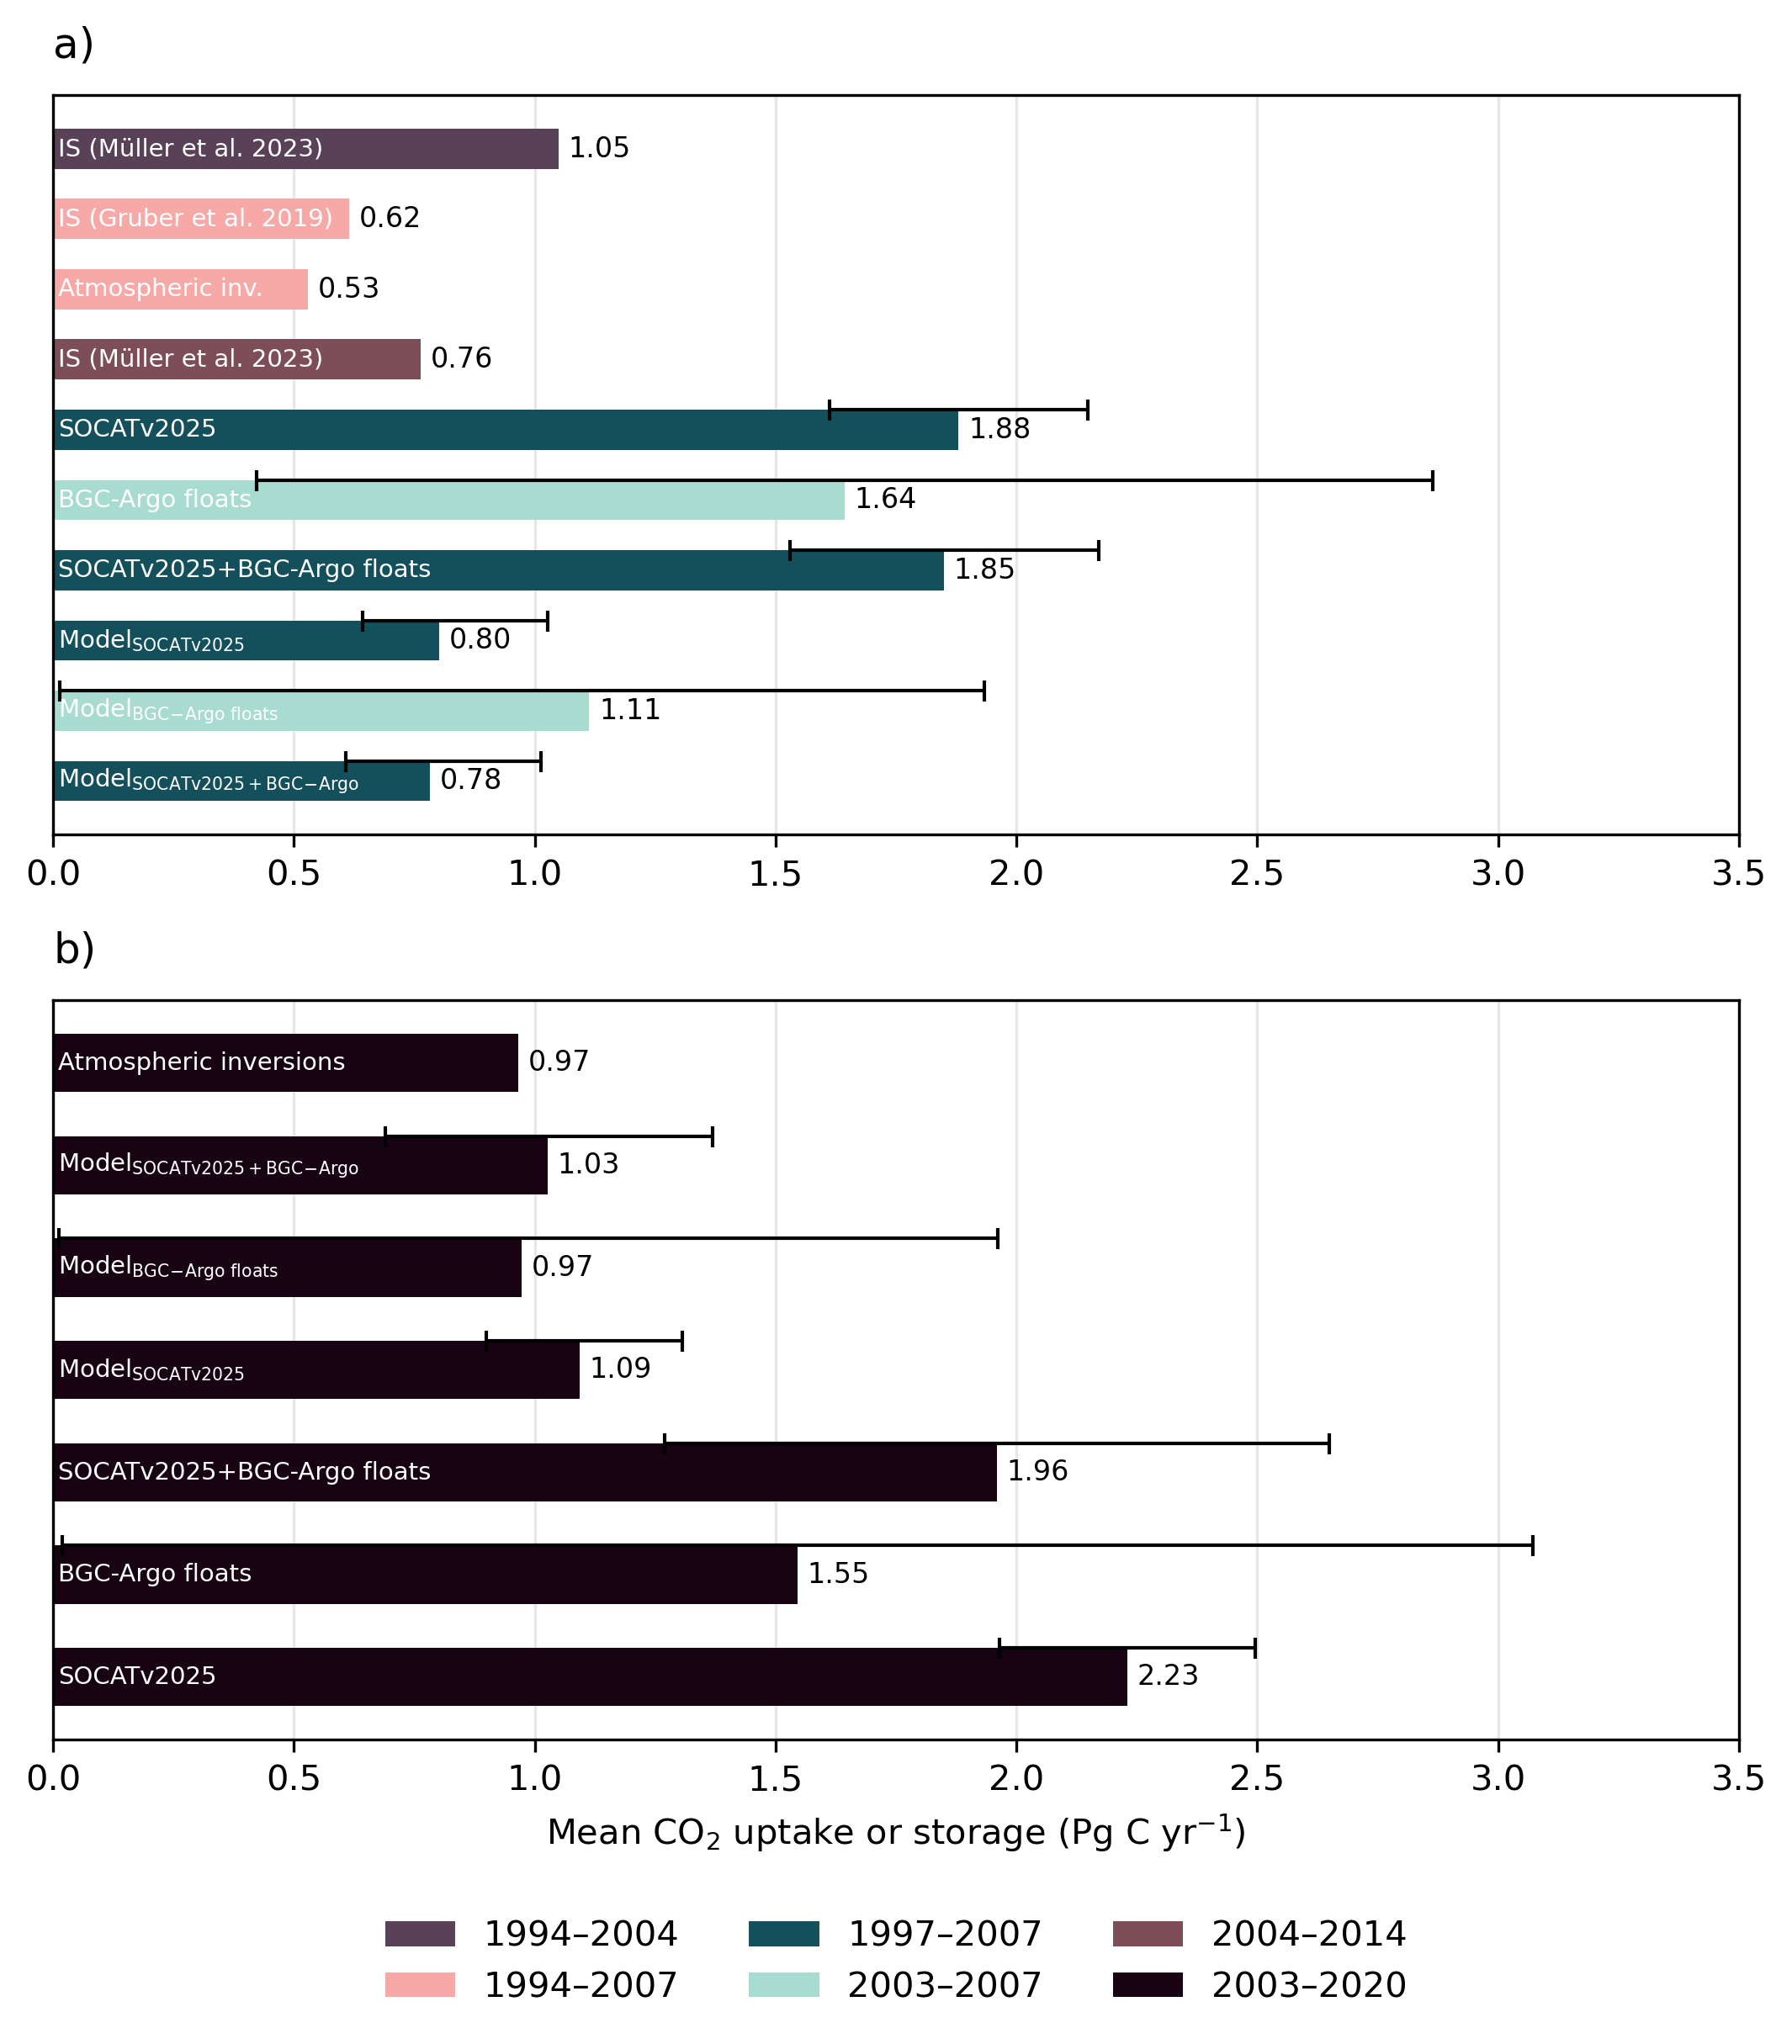

In [18]:
# ===========================
# 2-PANEL SUMMARY BAR FIGURE
# (with Müller et al. 2023 storage added to Panel a)
# ===========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- window colors ---
window_colors = {
    '1994–2007': '#F7A9A8',  # Gruber / long inversions
    '1997–2007': '#13505B',  # SOCAT-era
    '2003–2007': '#A8DCD1',  # floats-era
    '2003–2020': '#170312',  # extended period
    '1994–2004': '#594157',  # Müller period 1
    '2004–2014': '#7D4E57',  # Müller period 2
}

# --- label mapping ---
label_map = {
    'SOCAT': 'SOCATv2025',
    'Floats': 'BGC-Argo floats',
    'SOCAT+Floats': 'SOCATv2025+BGC-Argo floats',
    'SOCAT_predictions': r'Model$_{\mathrm{SOCATv2025}}$',
    'FLOATS_predictions': r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    'SOCAT_AND_FLOATS_predictions': r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Atmospheric inversions': 'Atmospheric inversions',
}

# --- helper: mean over year window from yearly_flux_summary ---
SUF = '_PgC_yr_fullarea'

def window_mean(df, col, y0, y1):
    if col not in df.columns:
        return np.nan
    sl = df[(df['year'] >= y0) & (df['year'] <= y1)]
    return float(sl[col].mean(skipna=True)) if len(sl) else np.nan

def series_stats(base, y0, y1, yfs):
    mean_col = base + SUF
    if 'predictions' in base and 'FLOATS' in base:
        low_col, high_col = base + '_low' + SUF, base + '_high' + SUF
    elif 'SOCAT_AND_FLOATS_predictions' in base:
        low_col, high_col = base + '_low' + SUF, None
    elif 'predictions' in base:
        low_col  = base + '_low'  + SUF
        high_col = base + '_high' + SUF
        if low_col not in yfs.columns or high_col not in yfs.columns:
            low_col = high_col = None
    else:
        low_col, high_col = base + '_low' + SUF, base + '_high' + SUF
        if low_col not in yfs.columns or high_col not in yfs.columns:
            low_col = high_col = None
    m  = window_mean(yfs, mean_col, y0, y1)
    lo = window_mean(yfs, low_col,  y0, y1) if low_col  else np.nan
    hi = window_mean(yfs, high_col, y0, y1) if high_col else np.nan
    if 'SOCAT_AND_FLOATS_predictions' in base and np.isfinite(lo) and not np.isfinite(hi):
        hi = 2*m - lo
    mag_mean, mag_low, mag_high = abs(m), abs(lo), abs(hi)
    xerr_left  = max(mag_mean - mag_high, 0.0) if np.isfinite(mag_high) else 0.0
    xerr_right = max(mag_low  - mag_mean, 0.0) if np.isfinite(mag_low)  else 0.0
    return mag_mean, xerr_left, xerr_right


# --- (optional) compute S35 if not already defined ---
if 'S35' not in globals():
    try:
        import xarray as xr
        dc = interior_anth['dcant']; vol = interior_vol['volume']
        dc, vol = xr.align(dc, vol, join='inner')
        so = dc['latitude'] <= -35.0
        mol_total = (dc.where(so) * vol.where(so)).sum(skipna=True)
        S35 = float((mol_total.values * 12.01) / 1e15 / 13.0)
    except Exception:
        pass


# --- Müller storage (S35_by_period) ---
if 'S35_by_period' not in globals():
    import xarray as xr
    anth_path = "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Muller2023/dcant_emlr_cstar_mueller_94-04-14.nc"
    vol_path  = "/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/inverse_fluxes/Muller2023/volume_mask_emlr_cstar_mueller_94-04-14.nc"
    interior_anth_mu = xr.load_dataset(anth_path)
    interior_vol_mu  = xr.load_dataset(vol_path)
    def _select_standard_case(da):
        confs = list(map(str, da["MLR_configuration"].values))
        masks = list(map(str, da["MLR_basin_mask"].values))
        conf_label = "Standard case" if "Standard case" in confs else confs[0]
        mask_label = "3" if "3" in masks else masks[0]
        return da.sel(MLR_configuration=conf_label, MLR_basin_mask=mask_label)
    dc_mu = _select_standard_case(interior_anth_mu["dcant"])
    vol3d_mu = interior_vol_mu[[v for v in interior_vol_mu.data_vars][0]]
    RHO, UMOL_TO_MOL, DECADE_YEARS, M_C, G_PER_PG = 1030.0, 1e-6, 10.0, 12.0, 1e15
    dc_molm3_per_year = dc_mu * UMOL_TO_MOL * RHO / DECADE_YEARS
    dc_molm3_per_year, vol3d_mu = xr.align(dc_molm3_per_year, vol3d_mu, join="inner")
    so_mask = dc_molm3_per_year["lat"] <= -35.0
    mol_yr = (dc_molm3_per_year.where(so_mask) * vol3d_mu.where(so_mask)).sum(dim=("depth","lat","lon"), skipna=True)
    pgc_yr = mol_yr * M_C / G_PER_PG
    S35_by_period = pd.Series([float(pgc_yr.sel(period=p)) for p in dc_molm3_per_year["period"].values],
                              index=list(map(str, dc_molm3_per_year["period"].values)), name="PgC_yr")


# --- build plot_df helper ---
def build_plot_df(specs, include_gruber=False, add_atm_inv=None):
    rows = []
    for base, y0, y1 in specs:
        m, xl, xr = series_stats(base, y0, y1, yearly_flux_summary)
        rows.append({'label': label_map.get(base, base), 'window': f'{y0}–{y1}',
                     'mag_mean': m, 'xerr_left': xl, 'xerr_right': xr})
    if include_gruber and 'S35' in globals() and np.isfinite(S35):
        rows.append({'label': 'IS (Gruber et al. 2019)', 'window': '1994–2007',
                     'mag_mean': abs(S35), 'xerr_left': np.nan, 'xerr_right': np.nan})
    if add_atm_inv is not None:
        start_date, end_date = add_atm_inv
        inv_mean, inv_std = atm_inversions_mean_std(ds, start_date, end_date)
        mag_mean = abs(inv_mean)
        bounds = [abs(inv_mean - inv_std), abs(inv_mean + inv_std)]
        mag_low, mag_high = min(bounds), max(bounds)
        rows.append({'label': label_map['Atmospheric inversions'],
                     'window': f"{pd.to_datetime(start_date).year}–{pd.to_datetime(end_date).year}",
                     'mag_mean': mag_mean,
                     'xerr_left': max(mag_mean - mag_high, 0.0),
                     'xerr_right': max(mag_low - mag_mean, 0.0)})
    return pd.DataFrame(rows)


# --- plotting helper (now inverts y-axis so first items are at TOP) ---
def plot_bar_panel(ax, plot_df, xlim=(0,3.5), set_xlabel=False, label_subs=None):
    bar_h, spacing = 0.20, 0.35
    ypos = np.arange(len(plot_df)) * spacing
    colors = plot_df['window'].map(window_colors).fillna('#999').tolist()
    bars = ax.barh(ypos, plot_df['mag_mean'], color=colors, height=bar_h, zorder=2)
    skip_err = plot_df['label'].str.startswith('IS (') | (plot_df['label'] == 'Atmospheric inversions')
    err_mask = (~skip_err) & np.isfinite(plot_df['mag_mean'])
    err_ypos = (ypos - (bar_h/2))[err_mask]
    xerr = np.vstack([plot_df.loc[err_mask,'xerr_left'].fillna(0).values,
                      plot_df.loc[err_mask,'xerr_right'].fillna(0).values])
    ax.errorbar(plot_df.loc[err_mask,'mag_mean'], err_ypos, xerr=xerr,
                fmt='none', ecolor='k', elinewidth=1, capsize=3, zorder=3)
    for bar,label in zip(bars,plot_df['label']):
        disp=(label_subs or {}).get(label,label)
        ax.text(0.01, bar.get_y()+bar.get_height()/2, disp,
                ha='left', va='center', fontsize=7, color='white', zorder=4)
    for bar,val in zip(bars,plot_df['mag_mean']):
        if np.isfinite(val):
            ax.text(bar.get_width()+0.02, bar.get_y()+bar.get_height()/2,
                    f"{val:.2f}", ha='left', va='center', fontsize=8, color='black', zorder=4)
    ax.set_xlim(*xlim); ax.set_yticks([])
    ax.invert_yaxis()  # << ensure first rows appear at TOP
    if set_xlabel:
        ax.set_xlabel("Mean CO$_2$ uptake or storage (Pg C yr$^{-1}$)")
    ax.grid(alpha=0.3, axis='x', zorder=1)


# -----------------
# PANEL (a)
# -----------------
spec_a = [
    ('SOCAT', 1997, 2007),
    ('Floats', 2003, 2007),
    ('SOCAT+Floats', 1997, 2007),
    ('SOCAT_predictions', 1997, 2007),
    ('FLOATS_predictions', 2003, 2007),
    ('SOCAT_AND_FLOATS_predictions', 1997, 2007),
]
plot_a = build_plot_df(spec_a, include_gruber=True, add_atm_inv=('1994-01-01','2007-12-31'))

# --- add Müller 1994–2004 & 2004–2014 ---
if 'S35_by_period' in globals() and isinstance(S35_by_period, pd.Series):
    def _disp(p): return str(p).replace(' - ', '–').replace('-', '–')
    mu_rows = [{'label':'IS (Müller et al. 2023)','window':_disp(p),
                'mag_mean':abs(float(v)),'xerr_left':np.nan,'xerr_right':np.nan}
               for p,v in S35_by_period.items()]
    mu_df = pd.DataFrame(mu_rows)
    plot_a = pd.concat([plot_a, mu_df], ignore_index=True)

    # ---- ORDER for panel (a): TOP four first, then the rest ----
    top_order = [
        ('IS (Müller et al. 2023)', '1994–2004'),
        ('IS (Gruber et al. 2019)', '1994–2007'),
        ('Atmospheric inversions',  '1994–2007'),
        ('IS (Müller et al. 2023)', '2004–2014'),
    ]
    base_order = [
        'SOCATv2025', 'BGC-Argo floats', 'SOCATv2025+BGC-Argo floats',
        r'Model$_{\mathrm{SOCATv2025}}$',
        r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
        r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    ]

    def order_key(row):
        for i,(lab,win) in enumerate(top_order):
            if row['label']==lab and row['window']==win:
                return i
        if row['label'] in base_order:
            return 10 + base_order.index(row['label'])
        return 999

    plot_a['order'] = plot_a.apply(order_key, axis=1)
    plot_a = plot_a.sort_values('order').reset_index(drop=True)


# -----------------
# PANEL (b)
# -----------------
spec_b = [
    ('SOCAT',                        2003, 2020),
    ('Floats',                       2003, 2020),
    ('SOCAT+Floats',                 2003, 2020),
    ('SOCAT_predictions',            2003, 2020),
    ('FLOATS_predictions',           2003, 2020),
    ('SOCAT_AND_FLOATS_predictions', 2003, 2020),
]
plot_b = build_plot_df(
    spec_b,
    include_gruber=False,
    add_atm_inv=('2003-01-01', '2020-12-31')
)

# --- enforce original order visually ---
order_b = [
    'SOCATv2025',
    'BGC-Argo floats',
    'SOCATv2025+BGC-Argo floats',
    r'Model$_{\mathrm{SOCATv2025}}$',
    r'Model$_{\mathrm{BGC\!-\!Argo\ floats}}$',
    r'Model$_{\mathrm{SOCATv2025+BGC\!-\!Argo}}$',
    'Atmospheric inversions'
]

plot_b['order'] = plot_b['label'].apply(lambda x: order_b.index(x) if x in order_b else len(order_b))
plot_b = plot_b.sort_values('order', ascending=False).reset_index(drop=True)


# -----------------
# DRAW FIGURE
# -----------------
xlim = (0, 3.5)
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(7.2,8.2),dpi=300,constrained_layout=False,sharex=False)

label_subs_a={'Atmospheric inversions':'Atmospheric inv.'}
plot_bar_panel(ax1,plot_a,xlim=xlim,set_xlabel=False,label_subs=label_subs_a)
ax1.text(0.0,1.04,'a)',transform=ax1.transAxes,fontsize=12,va='bottom',ha='left')

plot_bar_panel(ax2,plot_b,xlim=xlim,set_xlabel=True)
ax2.text(0.0,1.04,'b)',transform=ax2.transAxes,fontsize=12,va='bottom',ha='left')

legend_order=['1994–2004','1994–2007','1997–2007','2003–2007','2004–2014','2003–2020']
present=[w for w in legend_order if w in set(plot_a['window']).union(set(plot_b['window']))]
legend_handles=[Patch(facecolor=window_colors[w],edgecolor='none',label=w) for w in present]

fig.tight_layout(rect=[0,0.08,1,1])
fig.legend(handles=legend_handles,labels=present,
           loc='lower center', ncol=3,frameon=False,bbox_to_anchor=(0.5,0.01))

fig.savefig("/home/ldelaigue/Documents/Python/SOCAT-OSSE-SO/PREDICTION_MATRIX/figs/inversion_fluxes_summary_bars_two_panel.png",
            dpi=300,bbox_inches='tight')
plt.show()
